
# Sesión 02 — Modelos de Clasificación
**Ingeniería del Conocimiento (ISO56B)** · UNCP · 2026-II

**Docente:** Msc. Jaime Antonio Huaytalla Pariona

**Dataset:** Breast Cancer Wisconsin (569 muestras, 30 features, clasificación binaria)

---

## 1. Configuración del entorno

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    ConfusionMatrixDisplay, RocCurveDisplay
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


---
## 2. Carga y exploración del dataset

El dataset **Breast Cancer Wisconsin** contiene 569 muestras de biopsias de mama con 30 features numéricas computadas a partir de imágenes digitalizadas de aspiración con aguja fina (FNA). El target es binario: **maligno (0)** o **benigno (1)**.

In [66]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'maligno', 1: 'benigno'})

print(f'Dataset: {df.shape[0]} muestras, {df.shape[1]-2} features')
print(f'\nDistribución de clases:')
print(df['diagnosis'].value_counts())
print(f'\nProporción: {df["target"].mean():.1%} benigno, {1-df["target"].mean():.1%} maligno')

Dataset: 569 muestras, 30 features

Distribución de clases:
diagnosis
benigno    357
maligno    212
Name: count, dtype: int64

Proporción: 62.7% benigno, 37.3% maligno


In [67]:
df.describe().round(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,0.627
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,0.484
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,1.000
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,1.000
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208,1.000


---
## 3. Análisis exploratorio orientado a clasificación

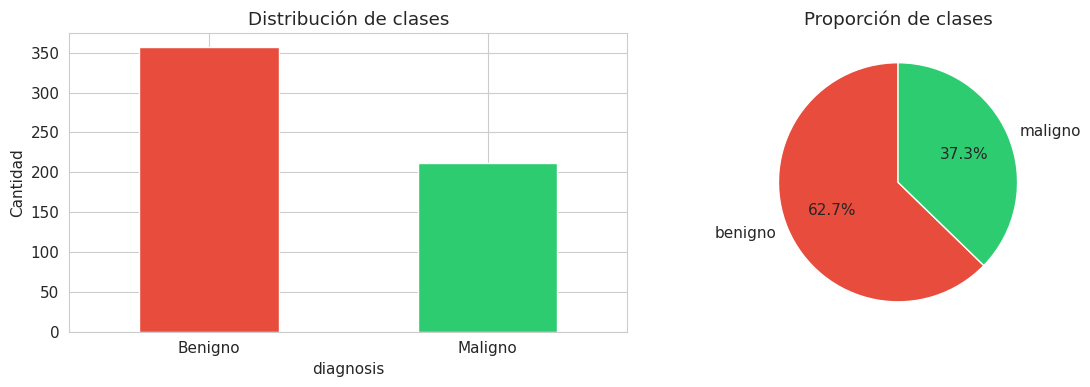

In [68]:
# 3.1  Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
colors = ['#e74c3c', '#2ecc71']
df['diagnosis'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['Benigno', 'Maligno'], rotation=0)

# Pie chart
df['diagnosis'].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
    autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

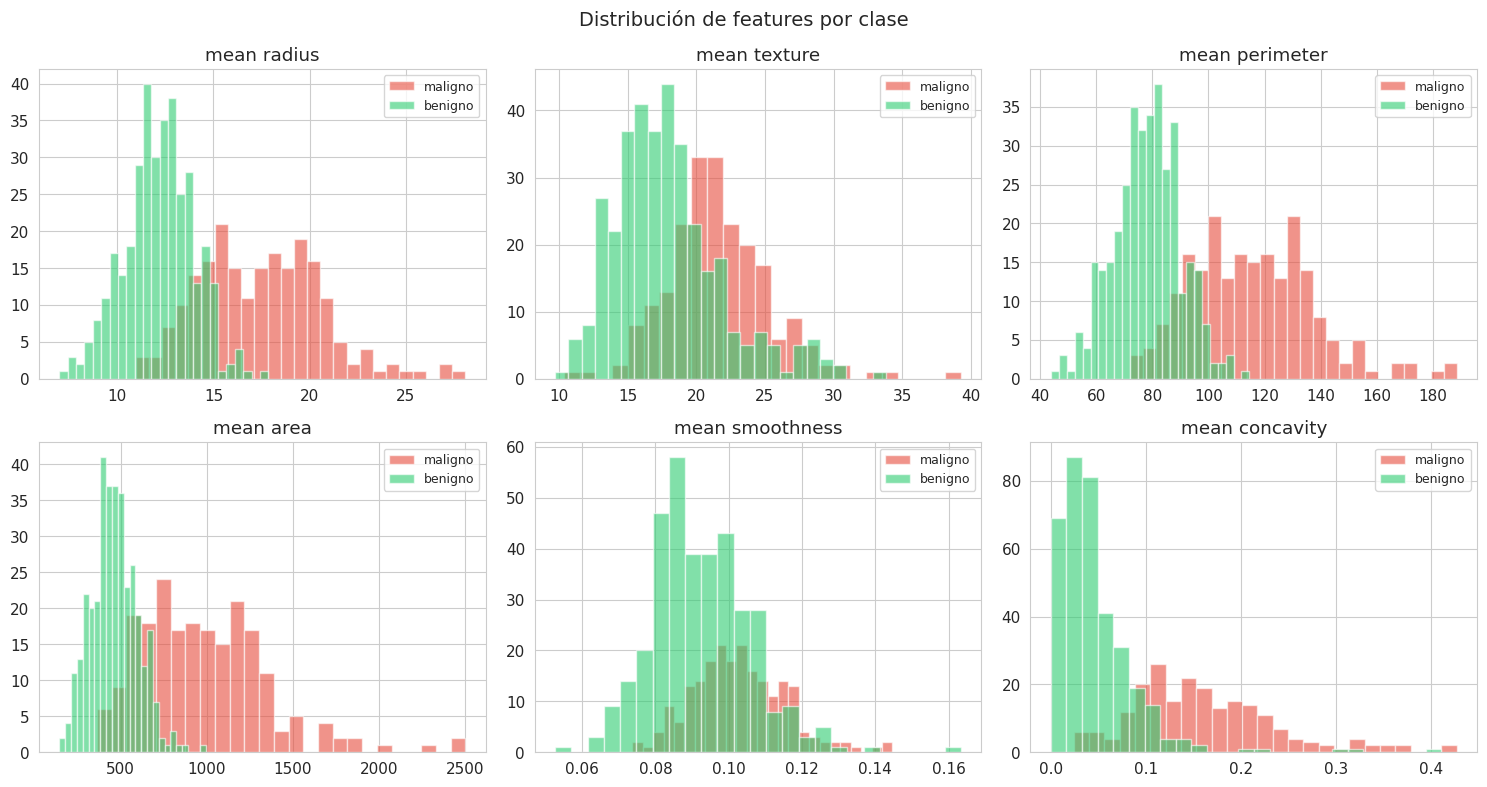

In [69]:
# 3.2  Distribución de features clave por clase
key_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness', 'mean concavity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(key_features):
    ax = axes[i//3, i%3]
    for label, color in zip([0, 1], colors):
        subset = df[df['target'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label='maligno' if label == 0 else 'benigno')
    ax.set_title(feat)
    ax.legend(fontsize=9)

plt.suptitle('Distribución de features por clase', fontsize=14)
plt.tight_layout()
plt.show()

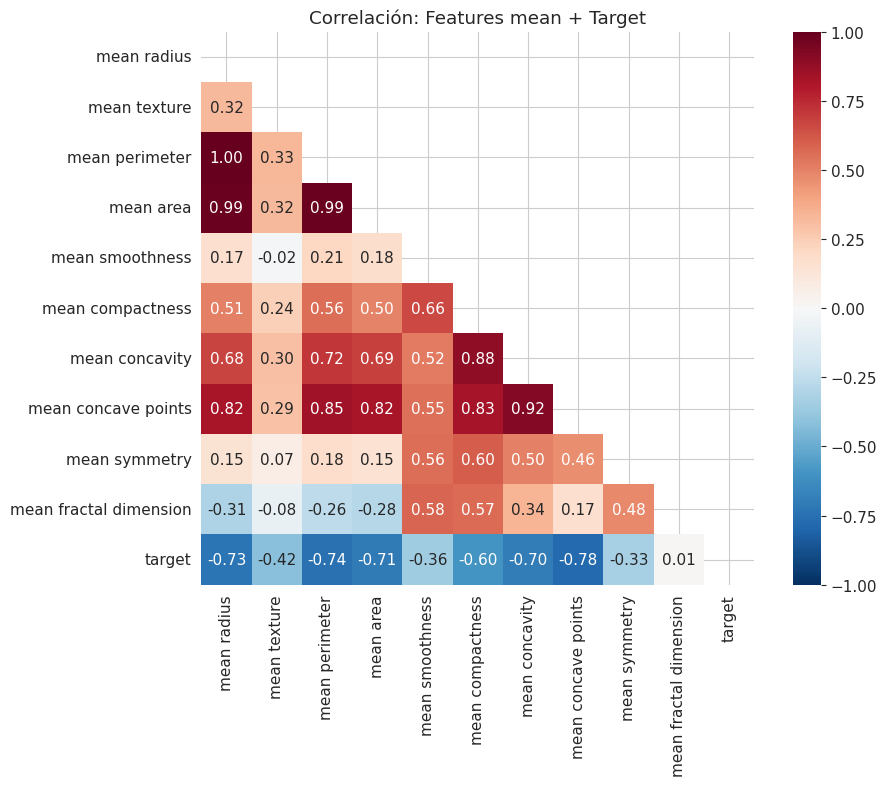

In [70]:
# 3.3  Matriz de correlación (features mean)
mean_features = [c for c in df.columns if 'mean' in c]
plt.figure(figsize=(10, 8))
corr = df[mean_features + ['target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlación: Features mean + Target')
plt.tight_layout()
plt.show()

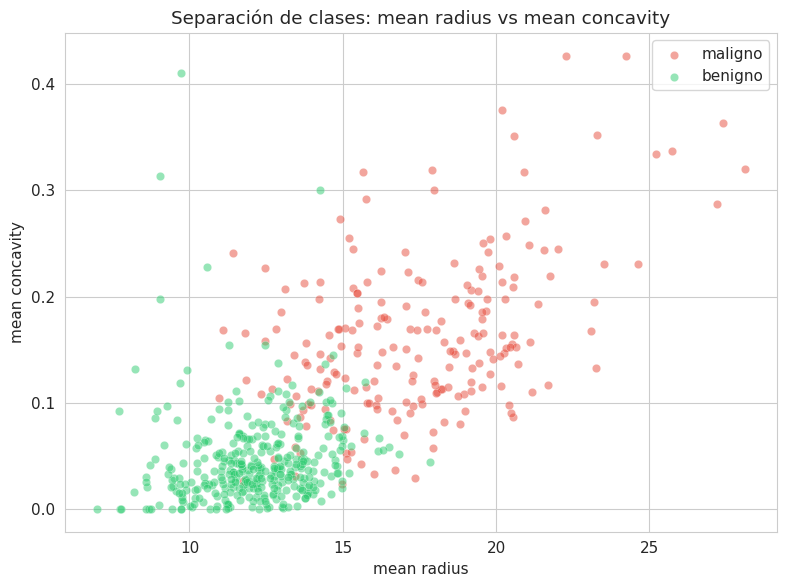

In [71]:
# 3.4  Scatter plot: 2 features más discriminativas
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1], colors, ['maligno', 'benigno']):
    mask = df['target'] == label
    ax.scatter(df.loc[mask, 'mean radius'], df.loc[mask, 'mean concavity'],
              alpha=0.5, c=color, label=name, edgecolors='w', linewidth=0.3)
ax.set_xlabel('mean radius')
ax.set_ylabel('mean concavity')
ax.set_title('Separación de clases: mean radius vs mean concavity')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [72]:
X = df[data.feature_names].copy()
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Test:          {X_test.shape[0]} muestras')
print(f'\nProporción en train: {y_train.mean():.1%} benigno')
print(f'Proporción en test:  {y_test.mean():.1%} benigno')

# Stratified K-Fold para validación cruzada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Entrenamiento: 455 muestras
Test:          114 muestras

Proporción en train: 62.6% benigno
Proporción en test:  63.2% benigno


### Funciones auxiliares para evaluación de clasificadores

In [73]:
def eval_classifier(model, X_tr, y_tr, X_te, y_te, model_name='Modelo'):
    """Evalúa un clasificador: métricas, matriz de confusión y reporte."""
    y_pred = model.predict(X_te)

    metrics = {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred),
        'F1-Score':  f1_score(y_te, y_pred)
    }

    print(f'=== {model_name} ===')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')

    # Matriz de confusión
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Maligno', 'Benigno'],
                yticklabels=['Maligno', 'Benigno'])
    axes[0].set_title(f'Matriz de Confusión — {model_name}')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')

    # Desglose FP y FN
    tn, fp, fn, tp = cm.ravel()
    labels = ['TN\n(benigno\ncorrecto)', 'FP\n(benigno→\nmaligno)',
              'FN\n(maligno→\nbenigno)', 'TP\n(maligno\ncorrecto)']
    values = [tn, fp, fn, tp]
    bar_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
    axes[1].bar(labels, values, color=bar_colors)
    axes[1].set_title(f'Desglose — {model_name}')
    axes[1].set_ylabel('Cantidad')

    plt.tight_layout()
    plt.show()

    print(f'\n  FN (maligno no detectado): {fn}')
    print(f'  FP (benigno como maligno): {fp}')
    print(f'\nReporte completo:')
    print(classification_report(y_te, y_pred,
          target_names=['maligno', 'benigno']))

    return metrics


def plot_roc(model, X_te, y_te, model_name='Modelo', ax=None):
    """Genera la curva ROC de un modelo."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_te)
    else:
        print(f'{model_name}: no soporta probabilidades')
        return None

    fpr, tpr, _ = roc_curve(y_te, y_score)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, linewidth=2,
            label=f'{model_name} (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'Curva ROC — {model_name}')
    ax.legend()

    return roc_auc

---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima P(y=1|x) mediante la función sigmoide σ(z) = 1/(1+e^(−z)). La frontera de decisión es lineal en el espacio de features. Se optimiza minimizando la Log-Loss (entropía cruzada binaria) con regularización L2 por defecto.

In [74]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Validación cruzada estratificada
cv_lr = cross_validate(pipe_lr, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Regresión Logística — Cross-Validation (5-fold)')
print(f'  Accuracy:  {cv_lr["test_accuracy"].mean():.4f} ± {cv_lr["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_lr["test_f1"].mean():.4f} ± {cv_lr["test_f1"].std():.4f}')
print(f'  Recall:    {cv_lr["test_recall"].mean():.4f} ± {cv_lr["test_recall"].std():.4f}')

# Entrenar modelo final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Regresión Logística — Cross-Validation (5-fold)
  Accuracy:  0.9780 ± 0.0098
  F1-Score:  0.9825 ± 0.0078
  Recall:    0.9860 ± 0.0131


=== Regresión Logística ===
  Accuracy: 0.9825
  Precision: 0.9861
  Recall: 0.9861
  F1-Score: 0.9861


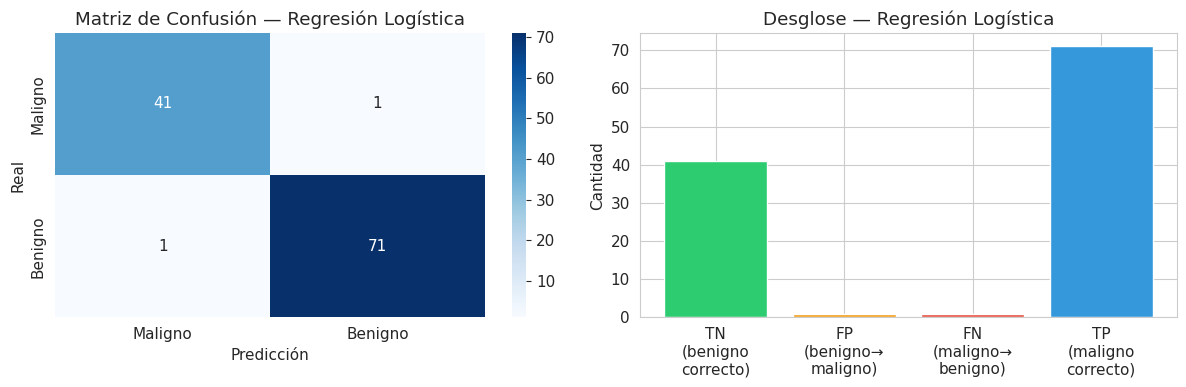


  FN (maligno no detectado): 1
  FP (benigno como maligno): 1

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        42
     benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [75]:
# 5.2  Evaluación completa
metrics_lr = eval_classifier(pipe_lr, X_train, y_train, X_test, y_test,
                             'Regresión Logística')

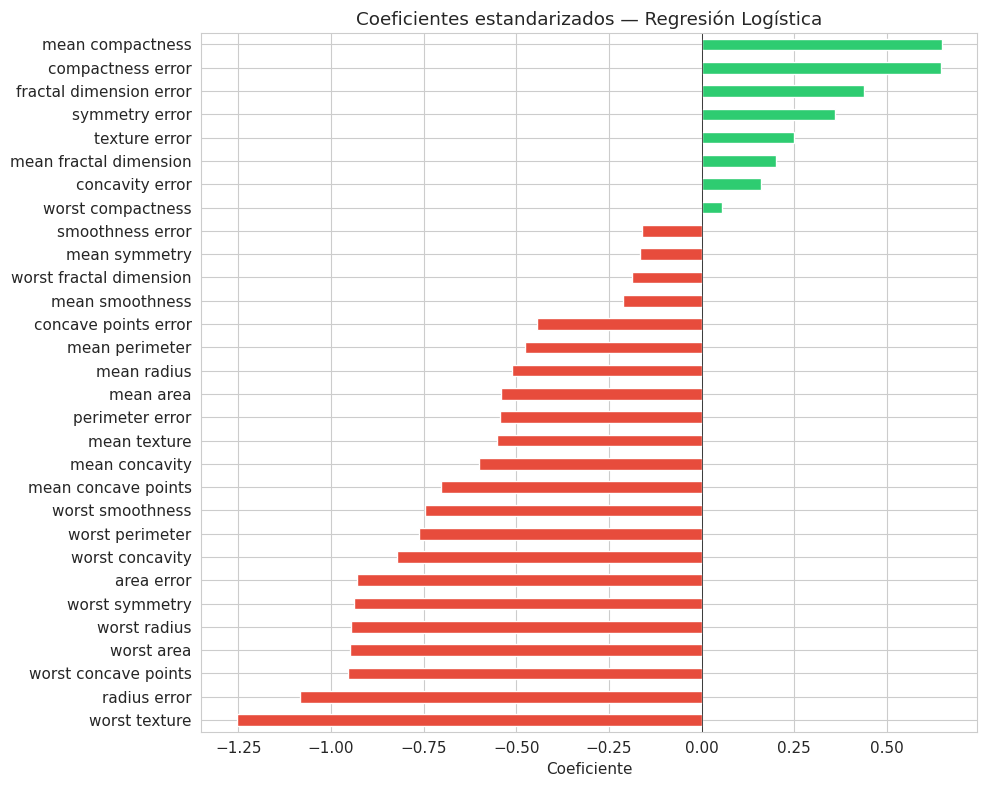

Interpretación:
  → Features que más indican MALIGNO: ['worst texture', 'radius error', 'worst concave points']
  → Features que más indican BENIGNO: ['fractal dimension error', 'compactness error', 'mean compactness']


In [76]:
# 5.3  Coeficientes estandarizados
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=data.feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs]
coefs.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('Coeficientes estandarizados — Regresión Logística')
ax.set_xlabel('Coeficiente')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'  → Features que más indican MALIGNO: {coefs.head(3).index.tolist()}')
print(f'  → Features que más indican BENIGNO: {coefs.tail(3).index.tolist()}')

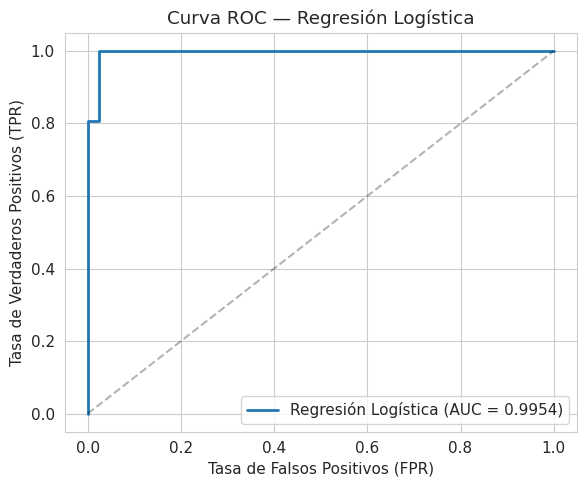

AUC: 0.9954


In [77]:
# 5.4  Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
auc_lr = plot_roc(pipe_lr, X_test, y_test, 'Regresión Logística', ax)
plt.tight_layout()
plt.show()
print(f'AUC: {auc_lr:.4f}')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** CART construye particiones recursivas del espacio de features. En cada nodo selecciona la feature y el umbral que maximizan la reducción de impureza (Gini: G(t) = 1 − Σpₖ²). Las particiones son ortogonales a los ejes.

In [78]:
# 6.1  Árbol sin restricciones (para mostrar sobreajuste)
pipe_dt_full = Pipeline([
    ('clf', DecisionTreeClassifier(random_state=42))
])

cv_dt_full = cross_validate(pipe_dt_full, X_train, y_train, cv=skf,
                            scoring=['accuracy', 'f1', 'recall'],
                            return_train_score=True)

print('Árbol de Decisión (SIN restricciones) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt_full["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt_full["test_accuracy"].mean():.4f} ± {cv_dt_full["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt_full["test_f1"].mean():.4f} ± {cv_dt_full["test_f1"].std():.4f}')
print(f'\n⚠ Train accuracy ~1.0 indica sobreajuste')

Árbol de Decisión (SIN restricciones) — CV 5-fold
  Train Accuracy: 1.0000
  Test Accuracy:  0.9165 ± 0.0179
  Test F1-Score:  0.9319 ± 0.0144

⚠ Train accuracy ~1.0 indica sobreajuste


In [79]:
# 6.2  Árbol con pre-poda
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

cv_dt = cross_validate(pipe_dt, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Árbol de Decisión (con pre-poda) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt["test_accuracy"].mean():.4f} ± {cv_dt["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt["test_f1"].mean():.4f} ± {cv_dt["test_f1"].std():.4f}')
print(f'  Test Recall:    {cv_dt["test_recall"].mean():.4f} ± {cv_dt["test_recall"].std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Árbol de Decisión (con pre-poda) — CV 5-fold
  Train Accuracy: 0.9747
  Test Accuracy:  0.9275 ± 0.0226
  Test F1-Score:  0.9417 ± 0.0189
  Test Recall:    0.9368 ± 0.0325


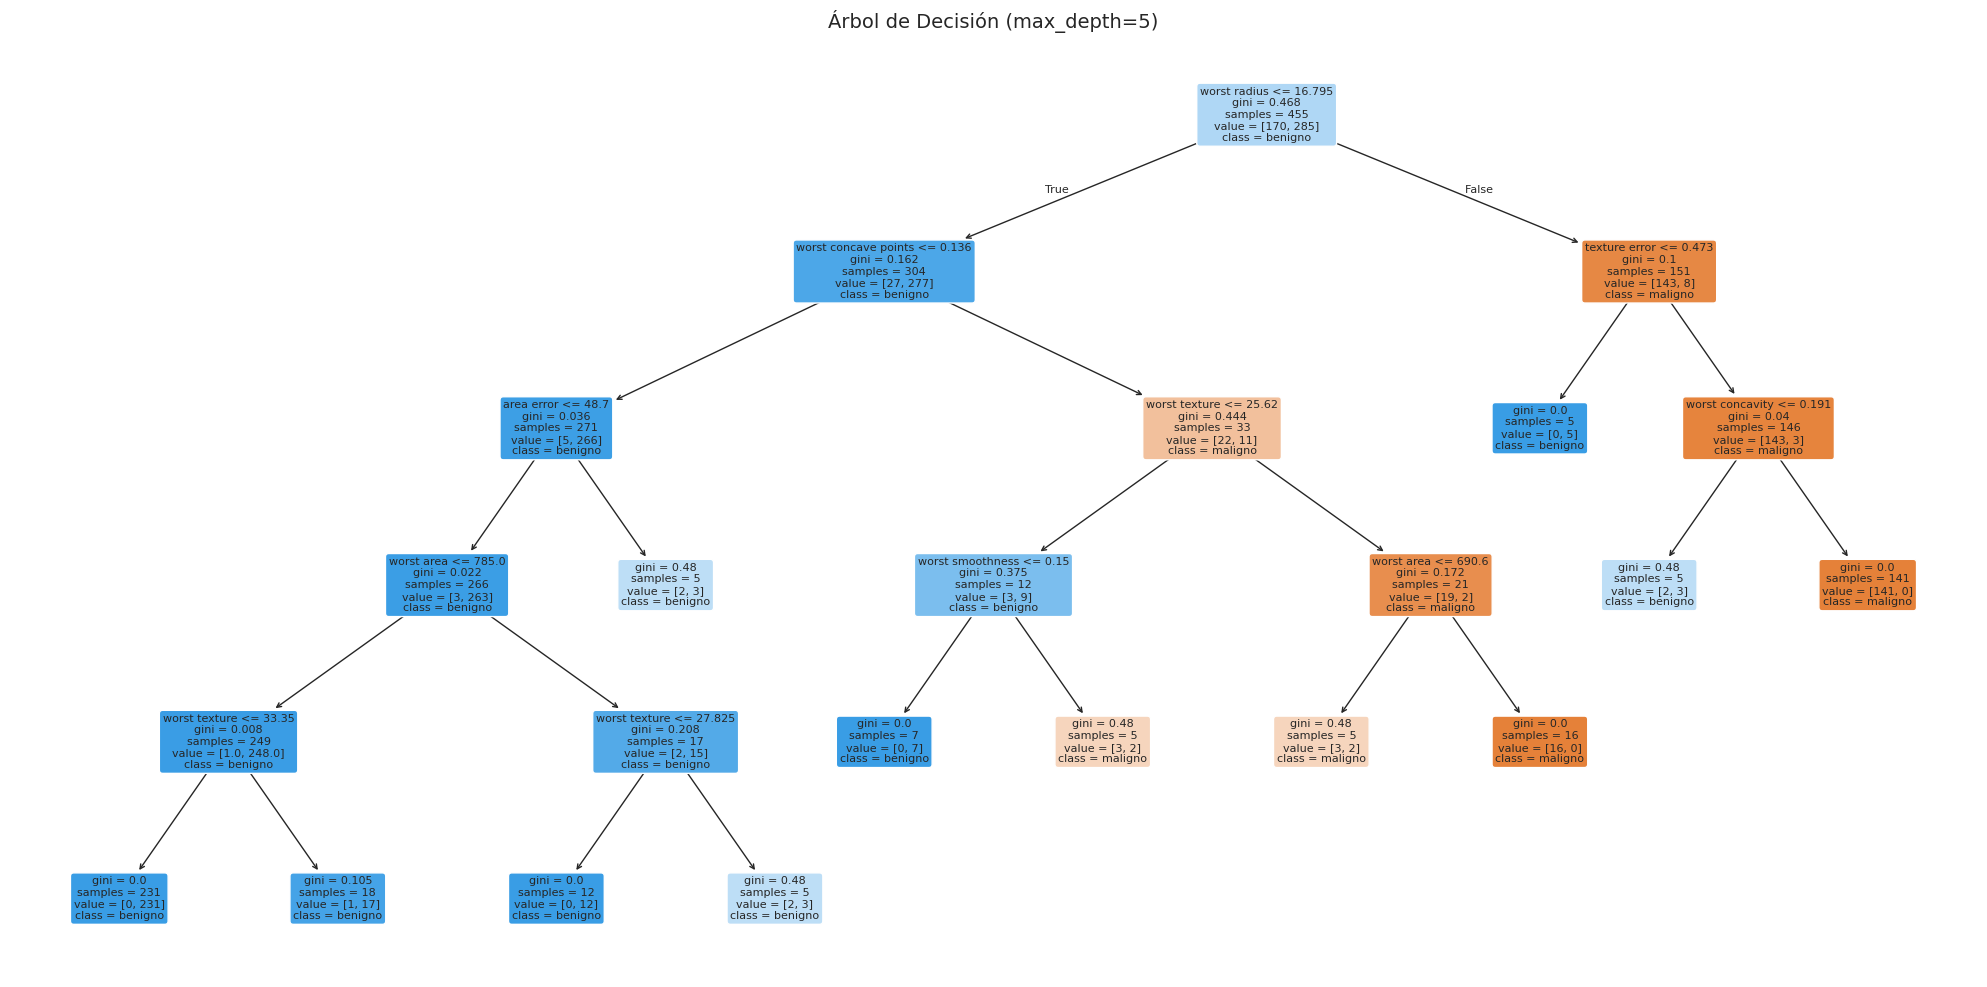

In [80]:
# 6.3  Visualización del árbol podado
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(pipe_dt.named_steps['clf'],
          feature_names=data.feature_names,
          class_names=['maligno', 'benigno'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Árbol de Decisión (max_depth=5)', fontsize=14)
plt.tight_layout()
plt.show()

=== Árbol de Decisión ===
  Accuracy: 0.9211
  Precision: 0.9437
  Recall: 0.9306
  F1-Score: 0.9371


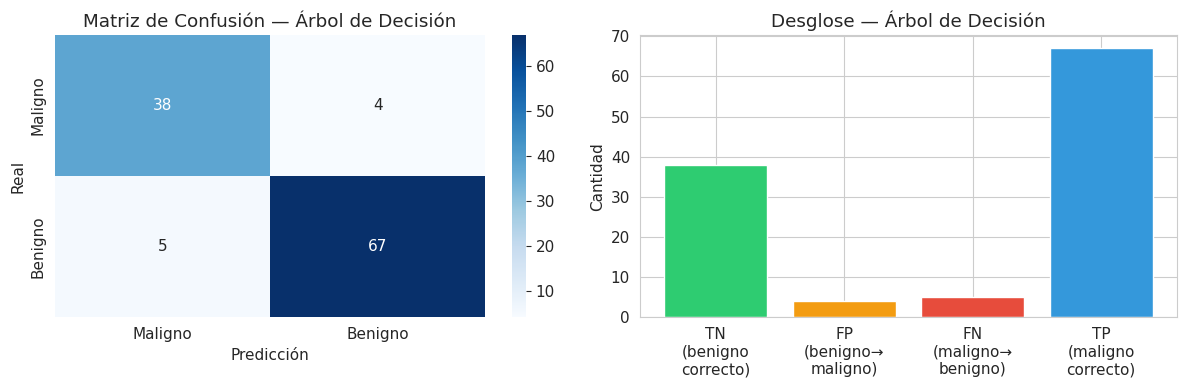


  FN (maligno no detectado): 5
  FP (benigno como maligno): 4

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.88      0.90      0.89        42
     benigno       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



In [81]:
# 6.4  Evaluación completa
metrics_dt = eval_classifier(pipe_dt, X_train, y_train, X_test, y_test,
                             'Árbol de Decisión')

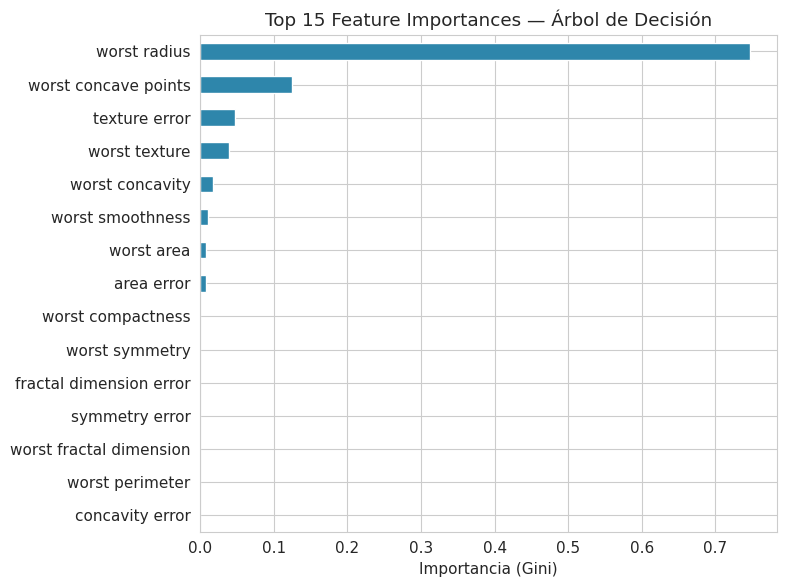

In [82]:
# 6.5  Importancia de features
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=data.feature_names
).sort_values(ascending=True)

# Top 15
top_imp = importances.tail(15)
fig, ax = plt.subplots(figsize=(8, 6))
top_imp.plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Top 15 Feature Importances — Árbol de Decisión')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

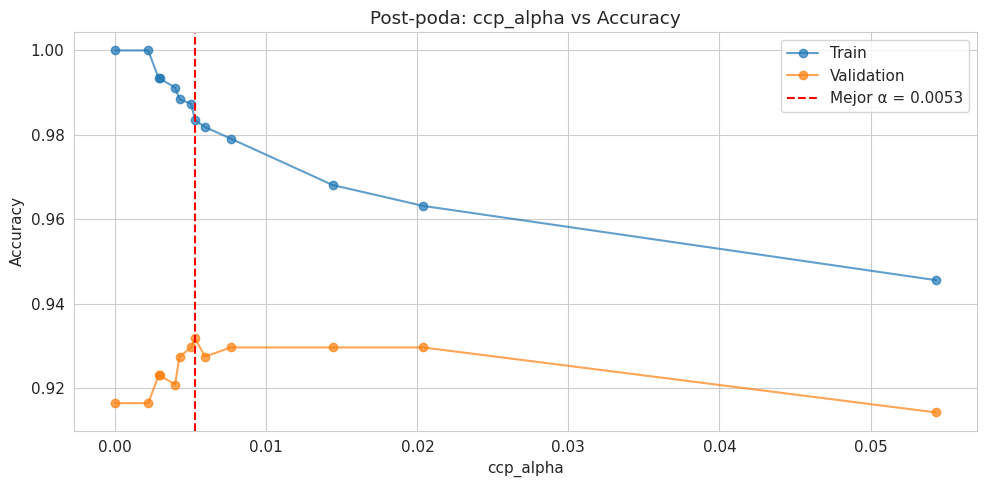

Mejor ccp_alpha: 0.005275


In [83]:
# 6.6  Post-poda con ccp_alpha
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]  # excluir el último (árbol trivial)

train_scores, test_scores = [], []
for alpha in alphas:
    dt_temp = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    cv_temp = cross_validate(dt_temp, X_train, y_train, cv=skf,
                             scoring='accuracy', return_train_score=True)
    train_scores.append(cv_temp['train_score'].mean())
    test_scores.append(cv_temp['test_score'].mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, train_scores, 'o-', label='Train', alpha=0.7)
ax.plot(alphas, test_scores, 'o-', label='Validation', alpha=0.7)
best_idx = np.argmax(test_scores)
ax.axvline(x=alphas[best_idx], color='red', linestyle='--',
           label=f'Mejor α = {alphas[best_idx]:.4f}')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Accuracy')
ax.set_title('Post-poda: ccp_alpha vs Accuracy')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mejor ccp_alpha: {alphas[best_idx]:.6f}')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** SVM busca el hiperplano de máximo margen γ = 2/‖w‖ que separa las clases. Con margen suave, permite violaciones controladas: min ½‖w‖² + C·Σξᵢ. El kernel trick transforma el espacio para manejar no linealidad.

In [84]:
# 7.1  Pipeline SVM con kernel RBF
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
])

cv_svm = cross_validate(pipe_svm, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('SVM (RBF, C=1.0) — CV 5-fold')
print(f'  Accuracy:  {cv_svm["test_accuracy"].mean():.4f} ± {cv_svm["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_svm["test_f1"].mean():.4f} ± {cv_svm["test_f1"].std():.4f}')
print(f'  Recall:    {cv_svm["test_recall"].mean():.4f} ± {cv_svm["test_recall"].std():.4f}')

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)

SVM (RBF, C=1.0) — CV 5-fold
  Accuracy:  0.9692 ± 0.0146
  F1-Score:  0.9756 ± 0.0113
  Recall:    0.9789 ± 0.0131


=== SVM (RBF) ===
  Accuracy: 0.9825
  Precision: 0.9861
  Recall: 0.9861
  F1-Score: 0.9861


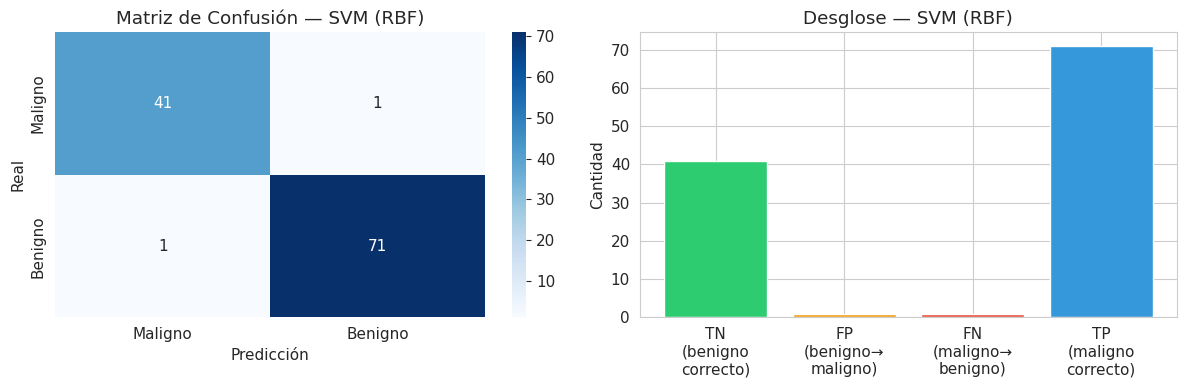


  FN (maligno no detectado): 1
  FP (benigno como maligno): 1

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        42
     benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [85]:
# 7.2  Evaluación completa
metrics_svm = eval_classifier(pipe_svm, X_train, y_train, X_test, y_test, 'SVM (RBF)')

  Kernel linear  : Accuracy = 0.9648
  Kernel rbf     : Accuracy = 0.9692
  Kernel poly    : Accuracy = 0.8967


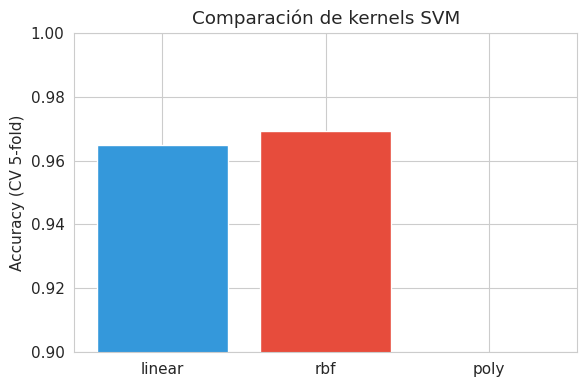

In [86]:
# 7.3  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
kernel_results = {}

for k in kernels:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=k, C=1.0, probability=True, random_state=42))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring='accuracy')
    kernel_results[k] = cv_k['test_score'].mean()
    print(f'  Kernel {k:8s}: Accuracy = {kernel_results[k]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(kernel_results.keys(), kernel_results.values(), color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Comparación de kernels SVM')
ax.set_ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

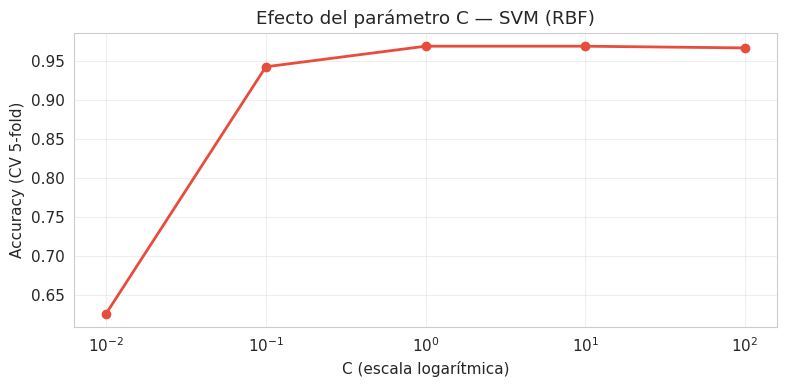


Interpretación:
  C bajo → margen amplio, más errores permitidos (mayor sesgo)
  C alto → margen estrecho, menos errores permitidos (mayor varianza)


In [87]:
# 7.4  Efecto del parámetro C
C_values = [0.01, 0.1, 1, 10, 100]
c_scores = []

for c in C_values:
    pipe_c = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=c, random_state=42))
    ])
    cv_c = cross_validate(pipe_c, X_train, y_train, cv=skf, scoring='accuracy')
    c_scores.append(cv_c['test_score'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_values, c_scores, 'o-', color='#e74c3c', linewidth=2)
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Efecto del parámetro C — SVM (RBF)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nInterpretación:')
print('  C bajo → margen amplio, más errores permitidos (mayor sesgo)')
print('  C alto → margen estrecho, menos errores permitidos (mayor varianza)')

---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Algoritmo de aprendizaje basado en instancias (lazy learning). No construye un modelo explícito; clasifica por voto mayoritario de los K vecinos más cercanos según distancia Euclidiana (por defecto). La regla empírica sugiere K ≈ √n.

In [88]:
# 8.1  Pipeline KNN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

cv_knn = cross_validate(pipe_knn, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('KNN (K=5) — CV 5-fold')
print(f'  Accuracy:  {cv_knn["test_accuracy"].mean():.4f} ± {cv_knn["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_knn["test_f1"].mean():.4f} ± {cv_knn["test_f1"].std():.4f}')
print(f'  Recall:    {cv_knn["test_recall"].mean():.4f} ± {cv_knn["test_recall"].std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=5) — CV 5-fold
  Accuracy:  0.9626 ± 0.0112
  F1-Score:  0.9705 ± 0.0091
  Recall:    0.9825 ± 0.0192


=== KNN (K=5) ===
  Accuracy: 0.9561
  Precision: 0.9589
  Recall: 0.9722
  F1-Score: 0.9655


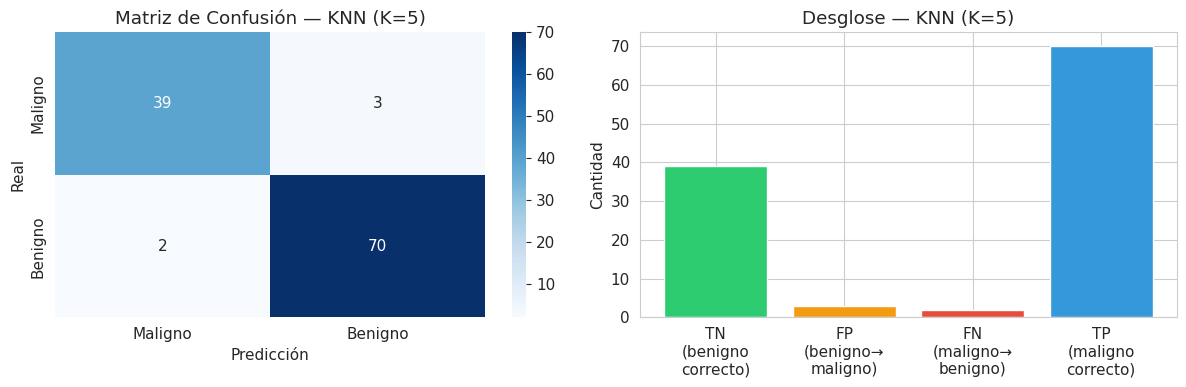


  FN (maligno no detectado): 2
  FP (benigno como maligno): 3

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.95      0.93      0.94        42
     benigno       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [89]:
# 8.2  Evaluación completa
metrics_knn = eval_classifier(pipe_knn, X_train, y_train, X_test, y_test, 'KNN (K=5)')

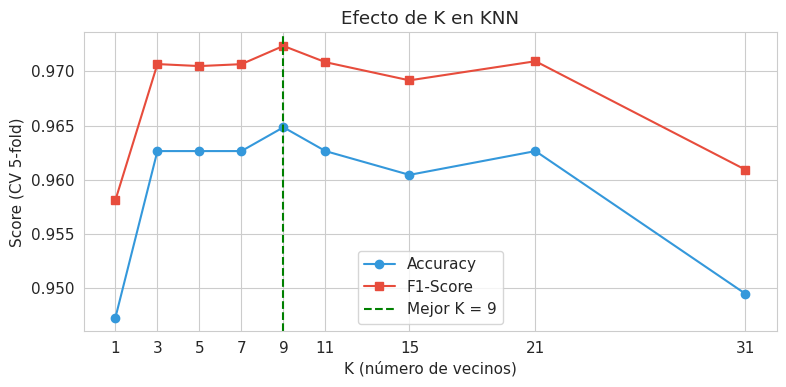

Mejor K por F1: 9
K empírico (√455): 21


In [90]:
# 8.3  Búsqueda del K óptimo
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_scores_acc = []
k_scores_f1 = []

for k in k_values:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring=['accuracy', 'f1'])
    k_scores_acc.append(cv_k['test_accuracy'].mean())
    k_scores_f1.append(cv_k['test_f1'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, k_scores_acc, 'o-', label='Accuracy', color='#3498db')
ax.plot(k_values, k_scores_f1, 's-', label='F1-Score', color='#e74c3c')
best_k = k_values[np.argmax(k_scores_f1)]
ax.axvline(x=best_k, color='green', linestyle='--', label=f'Mejor K = {best_k}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('Score (CV 5-fold)')
ax.set_title('Efecto de K en KNN')
ax.legend()
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

print(f'Mejor K por F1: {best_k}')
print(f'K empírico (√{len(X_train)}): {int(np.sqrt(len(X_train)))}')

In [91]:
# 8.4  Comparación de métricas de distancia
distances = ['euclidean', 'manhattan', 'minkowski']
dist_results = {}

for d in distances:
    p_val = 3 if d == 'minkowski' else 2
    pipe_d = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5, metric=d, p=p_val))
    ])
    cv_d = cross_validate(pipe_d, X_train, y_train, cv=skf, scoring='f1')
    dist_results[d] = cv_d['test_score'].mean()
    label = f'{d} (p={p_val})' if d == 'minkowski' else d
    print(f'  Distancia {label:20s}: F1 = {dist_results[d]:.4f}')

  Distancia euclidean           : F1 = 0.9705
  Distancia manhattan           : F1 = 0.9705
  Distancia minkowski (p=3)     : F1 = 0.9658


---
## 9. Comparación final de modelos

In [92]:
# 9.1  Tabla resumen de métricas
all_models = {
    'Regresión Logística': pipe_lr,
    'Árbol de Decisión': pipe_dt,
    'SVM (RBF)': pipe_svm,
    'KNN (K=5)': pipe_knn
}

all_metrics = {}
for name, model in all_models.items():
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc_val = auc(fpr, tpr)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc_val = auc(fpr, tpr)
    else:
        roc_auc_val = None

    all_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_val
    }

metrics_df = pd.DataFrame(all_metrics).T.round(4)
print('=== Tabla comparativa de métricas (Test Set) ===')
metrics_df

=== Tabla comparativa de métricas (Test Set) ===


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.9825,0.9861,0.9861,0.9861,0.9954
Árbol de Decisión,0.9211,0.9437,0.9306,0.9371,0.9368
SVM (RBF),0.9825,0.9861,0.9861,0.9861,0.9950
KNN (K=5),0.9561,0.9589,0.9722,0.9655,0.9788


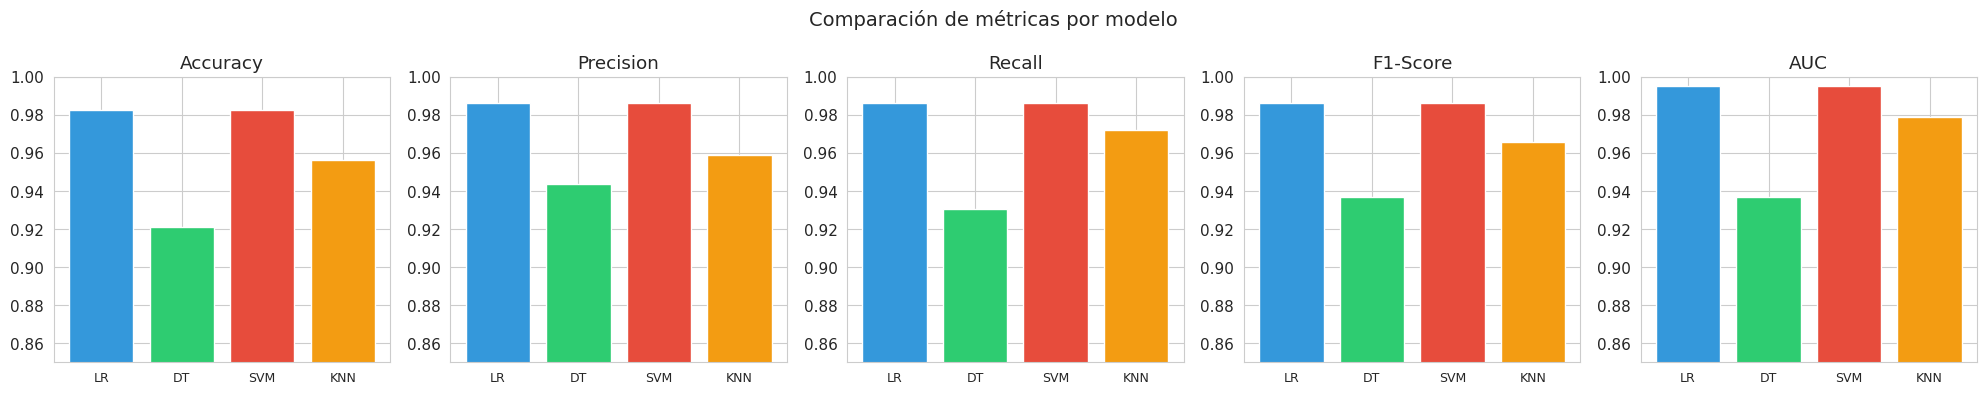

In [93]:
# 9.2  Gráfico de barras comparativo
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors_models = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, metric in enumerate(metric_names):
    values = [all_metrics[m][metric] for m in all_metrics]
    axes[i].bar(range(len(values)), values, color=colors_models)
    axes[i].set_title(metric)
    axes[i].set_ylim(0.85, 1.0)
    axes[i].set_xticks(range(len(values)))
    axes[i].set_xticklabels(['LR', 'DT', 'SVM', 'KNN'], fontsize=9)

plt.suptitle('Comparación de métricas por modelo', fontsize=14)
plt.tight_layout()
plt.show()

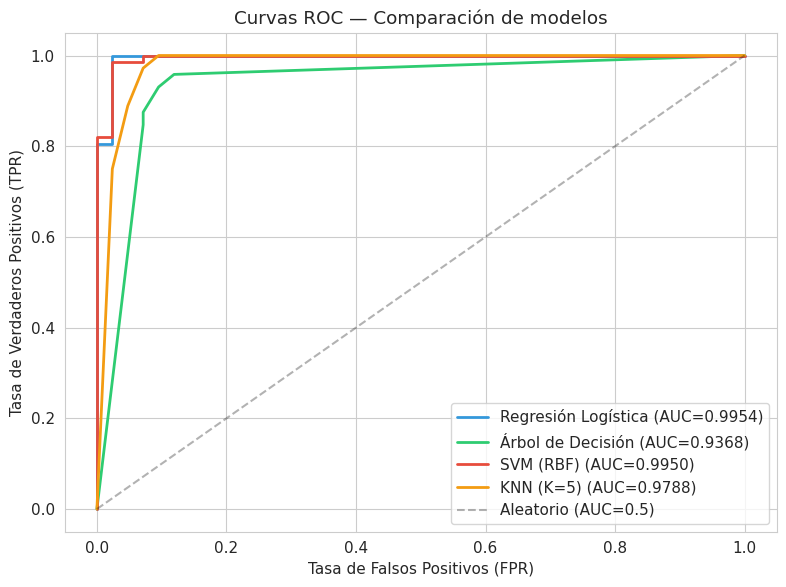

In [94]:
# 9.3  Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(all_models.items(), colors_models):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f'{name} (AUC={roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [95]:
# 9.4  Matriz de selección
selection_matrix = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'Árbol de Decisión', 'SVM (RBF)', 'KNN'],
    'Precisión predictiva': ['★★★★☆', '★★★☆☆', '★★★★★', '★★★★☆'],
    'Velocidad (train+pred)': ['★★★★★', '★★★★☆', '★★★☆☆', '★★★★★'],
    'Interpretabilidad': ['★★★★☆', '★★★★★', '★★☆☆☆', '★★★☆☆'],
    'Escalabilidad': ['★★★★★', '★★★★☆', '★★☆☆☆', '★★☆☆☆'],
    'Robustez a outliers': ['★★★☆☆', '★★★★☆', '★★★★☆', '★★☆☆☆']
}).set_index('Modelo')

print('=== Matriz de Selección de Modelos ===')
selection_matrix

=== Matriz de Selección de Modelos ===


,Precisión predictiva,Velocidad (train+pred),Interpretabilidad,Escalabilidad,Robustez a outliers
Modelo,,,,,
Reg. Logística,★★★★☆,★★★★★,★★★★☆,★★★★★,★★★☆☆
Árbol de Decisión,★★★☆☆,★★★★☆,★★★★★,★★★★☆,★★★★☆
SVM (RBF),★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆,★★★★☆
KNN,★★★★☆,★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆


---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Reg. Logística** | Interpretable, probabilístico, rápido | Asume linealidad en log-odds | Clasificación binaria con necesidad de interpretabilidad |
| **Árbol de Decisión** | Explicable, maneja tipos mixtos | Propenso a sobreajuste sin poda | Reglas de negocio, explicabilidad ante stakeholders |
| **SVM** | Efectivo en alta dimensión, robusto al ruido | Lento con muchos datos, difícil de interpretar | Datasets de dimensión media-alta, márgenes claros |
| **KNN** | Simple, no paramétrico, flexible | Lento en predicción, maldición de la dimensionalidad | Datasets pequeños-medianos con features normalizadas |

**Criterio de selección final:** En este dataset médico, **Recall** es la métrica prioritaria (minimizar falsos negativos). El modelo con mejor Recall en test es el candidato preferido para despliegue.

Optimización con GridSearchCV

In [96]:

print('OPTIMIZACIÓN CON GRIDSEARCHCV')


from sklearn.model_selection import GridSearchCV

# 1. Optimización de Regresión Logística
print('\n Buscando mejores parámetros para Regresión Logística...')
param_grid_lr = {'clf__C': [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    param_grid_lr, cv=5, scoring='f1', n_jobs=-1
)
grid_lr.fit(X_train, y_train)
print(f' Mejor LR: C = {grid_lr.best_params_["clf__C"]}, F1-Score = {grid_lr.best_score_:.4f}')

# 2. Optimización de Árbol de Decisión
print('\n Buscando mejores parámetros para Árbol de Decisión...')
param_grid_dt = {'clf__max_depth': [3, 5, 7, 10], 'clf__min_samples_leaf': [1, 5, 10]}
grid_dt = GridSearchCV(
    Pipeline([('clf', DecisionTreeClassifier(random_state=42))]),
    param_grid_dt, cv=5, scoring='f1', n_jobs=-1
)
grid_dt.fit(X_train, y_train)
print(f' Mejor DT: {grid_dt.best_params_}, F1-Score = {grid_dt.best_score_:.4f}')



OPTIMIZACIÓN CON GRIDSEARCHCV

 Buscando mejores parámetros para Regresión Logística...
 Mejor LR: C = 0.1, F1-Score = 0.9845

 Buscando mejores parámetros para Árbol de Decisión...
 Mejor DT: {'clf__max_depth': 5, 'clf__min_samples_leaf': 5}, F1-Score = 0.9500


 Manejo de Desbalance (class_weight y SMOTE)

In [97]:

print('MANEJO DE DESBALANCE (class_weight y SMOTE)')


# A) Usando class_weight='balanced'
print('\n1️ Probando con class_weight="balanced"...')
lr_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_balanced.fit(X_train, y_train)
y_pred_bal = lr_balanced.predict(X_test)

# Nota: en este dataset, 0 = maligno. Usamos pos_label=0 para medir el recall de la clase maligna.
recall_bal = recall_score(y_test, y_pred_bal, pos_label=0)
print(f'   → Recall (Maligno) con class_weight: {recall_bal:.4f}')

# B) Usando SMOTE (Sintetic Minority Over-sampling Technique)
print('\n2️ Probando con SMOTE...')
try:
    from imblearn.over_sampling import SMOTE

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    print(f'   • Tamaño de X_train original: {X_train.shape[0]}')
    print(f'   • Tamaño de X_train con SMOTE:  {X_train_smote.shape[0]} (¡Clases balanceadas!)')

    lr_smote = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])
    lr_smote.fit(X_train_smote, y_train_smote)
    y_pred_smote = lr_smote.predict(X_test)

    recall_smote = recall_score(y_test, y_pred_smote, pos_label=0)
    print(f'   → Recall (Maligno) con SMOTE: {recall_smote:.4f}')

except ImportError:
    print('   La librería "imbalanced-learn" no está instalada.')
    print('   Solución: Ejecuta esta celda: !pip install imbalanced-learn')

MANEJO DE DESBALANCE (class_weight y SMOTE)

1️ Probando con class_weight="balanced"...
   → Recall (Maligno) con class_weight: 0.9762

2️ Probando con SMOTE...
   • Tamaño de X_train original: 455
   • Tamaño de X_train con SMOTE:  570 (¡Clases balanceadas!)
   → Recall (Maligno) con SMOTE: 0.9762


---
## 11. Ejercicios propuestos

### Ejercicio 1 — Optimización con GridSearchCV
Para cada modelo, realice una búsqueda exhaustiva de hiperparámetros con `GridSearchCV(cv=5, scoring='f1')`. Parámetros sugeridos:
- **LogisticRegression:** C=[0.01, 0.1, 1, 10, 100]
- **DecisionTree:** max_depth=[3,5,7,10,None], min_samples_leaf=[1,5,10]
- **SVM:** C=[0.1,1,10], gamma=[0.001,0.01,0.1]
- **KNN:** n_neighbors=[3,5,9,15,21], weights=['uniform','distance']

Compare los mejores modelos optimizados.

### Ejercicio 2 — Manejo de desbalance con class_weight y SMOTE
Entrene los 4 modelos con `class_weight='balanced'`. Compare Recall de la clase maligna con y sin balanceo. Además, aplique SMOTE:
```python
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
```

### Ejercicio 3 — Dataset propio
Seleccione un dataset de clasificación de Kaggle/UCI (mín. 500 registros, 5 features). Aplique los 4 modelos + al menos 1 adicional (Random Forest, Gradient Boosting o Naive Bayes). Documente métricas, curvas ROC, matriz de selección y justificación del mejor modelo.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*

---
# Solución — Ejercicio 1: Optimización con GridSearchCV

Se ejecuta `GridSearchCV(cv=5, scoring='f1')` con las rejillas sugeridas para los 4 modelos (Regresión Logística, Árbol de Decisión, SVM y KNN) sobre el conjunto de entrenamiento, y luego se comparan los mejores modelos optimizados contra los modelos base de las secciones 5–8.

In [98]:
# Ejercicio 1 — Búsqueda exhaustiva de hiperparámetros con GridSearchCV (cv=5, scoring='f1')
import time
from sklearn.model_selection import GridSearchCV

grids = {
    'Regresión Logística': (
        Pipeline([('scaler', StandardScaler()),
                  ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
        {'clf__C': [0.01, 0.1, 1, 10, 100]}),
    'Árbol de Decisión': (
        Pipeline([('clf', DecisionTreeClassifier(random_state=42))]),
        {'clf__max_depth': [3, 5, 7, 10, None],
         'clf__min_samples_leaf': [1, 5, 10]}),
    'SVM (RBF)': (
        Pipeline([('scaler', StandardScaler()),
                  ('clf', SVC(kernel='rbf', random_state=42))]),
        {'clf__C': [0.1, 1, 10],
         'clf__gamma': [0.001, 0.01, 0.1]}),
    'KNN': (
        Pipeline([('scaler', StandardScaler()),
                  ('clf', KNeighborsClassifier())]),
        {'clf__n_neighbors': [3, 5, 9, 15, 21],
         'clf__weights': ['uniform', 'distance']})
}

best_models = {}   # mejor estimador de cada búsqueda (ya reentrenado con todo X_train)
grid_cv_f1 = {}    # mejor F1 en validación cruzada

for name, (pipe, grid) in grids.items():
    n_comb = int(np.prod([len(v) for v in grid.values()]))
    t0 = time.time()
    gs = GridSearchCV(pipe, grid, cv=5, scoring='f1', n_jobs=-1)
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_
    grid_cv_f1[name] = gs.best_score_
    params = {k.replace('clf__', ''): v for k, v in gs.best_params_.items()}
    print(f'{name}  ({n_comb} combinaciones x 5 folds, {time.time()-t0:.1f}s)')
    print(f'   Mejores parámetros: {params}')
    print(f'   F1-Score (CV):      {gs.best_score_:.4f}\n')


Regresión Logística  (5 combinaciones x 5 folds, 0.2s)
   Mejores parámetros: {'C': 0.1}
   F1-Score (CV):      0.9845

Árbol de Decisión  (15 combinaciones x 5 folds, 0.6s)
   Mejores parámetros: {'max_depth': 5, 'min_samples_leaf': 5}
   F1-Score (CV):      0.9500

SVM (RBF)  (9 combinaciones x 5 folds, 0.4s)
   Mejores parámetros: {'C': 10, 'gamma': 0.01}
   F1-Score (CV):      0.9844

KNN  (10 combinaciones x 5 folds, 0.3s)
   Mejores parámetros: {'n_neighbors': 3, 'weights': 'uniform'}
   F1-Score (CV):      0.9759



In [99]:
# Ejercicio 1 — Comparación de los mejores modelos optimizados vs. los modelos base
def score_model(model, X):
    """Score continuo para la ROC (probabilidad o función de decisión)."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)

base_models = {
    'Regresión Logística': pipe_lr,
    'Árbol de Decisión': pipe_dt,
    'SVM (RBF)': pipe_svm,
    'KNN': pipe_knn
}

rows = []
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, score_model(model, X_test))
    rows.append({
        'Modelo': name,
        'F1 (CV)': grid_cv_f1[name],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': auc(fpr, tpr),
        'Recall (Maligno)': recall_score(y_test, y_pred, pos_label=0),
        'F1 base (test)': f1_score(y_test, base_models[name].predict(X_test))
    })

opt_df = pd.DataFrame(rows).set_index('Modelo').round(4)
print('=== Modelos optimizados con GridSearchCV (métricas en Test Set) ===')
opt_df


=== Modelos optimizados con GridSearchCV (métricas en Test Set) ===


,F1 (CV),Accuracy,Precision,Recall,F1-Score,AUC,Recall (Maligno),F1 base (test)
Modelo,,,,,,,,
Regresión Logística,0.9845,0.9737,0.9726,0.9861,0.9793,0.9957,0.9524,0.9861
Árbol de Decisión,0.9500,0.9211,0.9437,0.9306,0.9371,0.9368,0.9048,0.9371
SVM (RBF),0.9844,0.9825,0.9861,0.9861,0.9861,0.9977,0.9762,0.9861
KNN,0.9759,0.9825,0.9730,1.0000,0.9863,0.9835,0.9524,0.9655


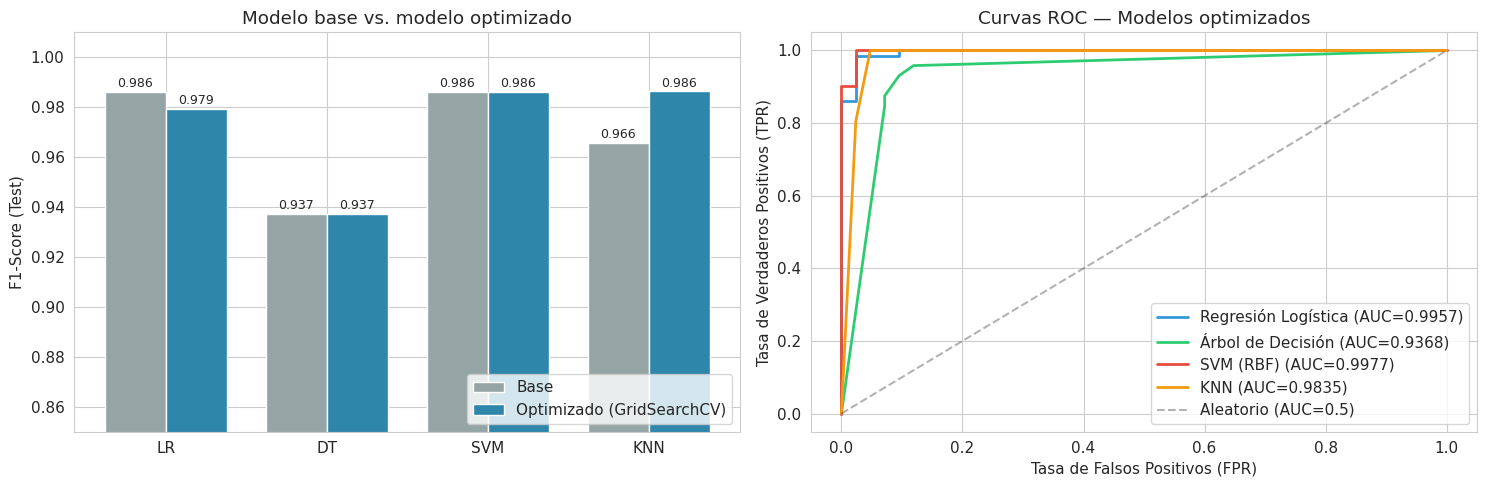

Mejor modelo por F1 en validación cruzada: Regresión Logística (0.9845)
Mejor modelo por F1 en test:               KNN (0.9863)


In [100]:
# Ejercicio 1 — Gráficos comparativos: base vs. optimizado y curvas ROC
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) F1 en test: modelo base vs. modelo optimizado
x = np.arange(len(opt_df))
w = 0.38
axes[0].bar(x - w/2, opt_df['F1 base (test)'], w, label='Base', color='#95a5a6')
axes[0].bar(x + w/2, opt_df['F1-Score'], w, label='Optimizado (GridSearchCV)', color='#2E86AB')
for xi, (b, o) in enumerate(zip(opt_df['F1 base (test)'], opt_df['F1-Score'])):
    axes[0].text(xi - w/2, b + 0.002, f'{b:.3f}', ha='center', fontsize=9)
    axes[0].text(xi + w/2, o + 0.002, f'{o:.3f}', ha='center', fontsize=9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['LR', 'DT', 'SVM', 'KNN'])
axes[0].set_ylim(0.85, 1.01)
axes[0].set_ylabel('F1-Score (Test)')
axes[0].set_title('Modelo base vs. modelo optimizado')
axes[0].legend(loc='lower right')

# (b) Curvas ROC de los modelos optimizados
for (name, model), color in zip(best_models.items(), colors_models):
    fpr, tpr, _ = roc_curve(y_test, score_model(model, X_test))
    axes[1].plot(fpr, tpr, linewidth=2, color=color,
                 label=f'{name} (AUC={auc(fpr, tpr):.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curvas ROC — Modelos optimizados')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

best_cv = max(grid_cv_f1, key=grid_cv_f1.get)
best_test = opt_df['F1-Score'].idxmax()
print(f'Mejor modelo por F1 en validación cruzada: {best_cv} ({grid_cv_f1[best_cv]:.4f})')
print(f'Mejor modelo por F1 en test:               {best_test} ({opt_df.loc[best_test, "F1-Score"]:.4f})')


**Conclusiones del Ejercicio 1**

- **Mejores hiperparámetros:** LR → `C=0.1`; Árbol → `max_depth=5, min_samples_leaf=5` (igual al árbol pre-podado del notebook); SVM → `C=10, gamma=0.01`; KNN → `n_neighbors=3, weights='uniform'`.
- **Validación cruzada (F1):** Regresión Logística (0.9845) y SVM (0.9844) quedan prácticamente empatadas, seguidas de KNN (0.9759) y del Árbol (0.9500).
- **Test Set:** el SVM optimizado mantiene F1 = 0.9861 y obtiene el mejor AUC (0.9977) y el mejor Recall de la clase maligna (0.9762, 1 solo maligno no detectado). KNN mejora con la optimización (F1 0.9655 → 0.9863) y detecta todos los benignos, pero deja escapar 2 malignos. La LR optimizada (C=0.1) no mejora en test frente a la base (C=1).
- **Modelo preferido:** SVM (RBF) optimizado, por su equilibrio entre F1 en CV, AUC y Recall de la clase maligna, que es la métrica prioritaria en este problema médico. Las diferencias entre LR, SVM y KNN en test equivalen a 1–2 muestras de 114, por lo que no son concluyentes.

---
# Solución — Ejercicio 2: Manejo de desbalance con class_weight y SMOTE

Se compara el **Recall de la clase maligna** (`pos_label=0`) de los modelos **sin balanceo**, con `class_weight='balanced'` y con **SMOTE** aplicado solo al conjunto de entrenamiento. En este dataset la clase maligna es la minoritaria (≈37 %).

In [101]:
# Ejercicio 2 — class_weight='balanced' en los 4 modelos
# Nota: en este dataset 0 = maligno, por eso el Recall de la clase maligna usa pos_label=0.

def recall_maligno(model, X, y):
    return recall_score(y, model.predict(X), pos_label=0)

def fn_maligno(model, X, y):
    """Malignos clasificados como benignos (falsos negativos de la clase maligna)."""
    return int(((y == 0) & (model.predict(X) == 1)).sum())

# Modelos base (sin balanceo) ya entrenados en las secciones anteriores
base_models = {
    'Regresión Logística': pipe_lr,
    'Árbol de Decisión': pipe_dt,
    'SVM (RBF)': pipe_svm,
    'KNN (K=5)': pipe_knn
}

# Mismos hiperparámetros que los modelos base, añadiendo class_weight='balanced'
balanced_models = {
    'Regresión Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))]),
    'Árbol de Decisión': Pipeline([
        ('clf', DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                       min_samples_split=10, min_samples_leaf=5,
                                       random_state=42))]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, class_weight='balanced',
                    probability=True, random_state=42))])
}
for m in balanced_models.values():
    m.fit(X_train, y_train)

print('Recall de la clase maligna (Test Set)')
print(f'{"Modelo":22s} {"Sin balanceo":>13s} {"class_weight":>13s}')
for name in base_models:
    r0 = recall_maligno(base_models[name], X_test, y_test)
    if name in balanced_models:
        r1 = f'{recall_maligno(balanced_models[name], X_test, y_test):.4f}'
    else:
        r1 = 'N/A'
    print(f'{name:22s} {r0:13.4f} {r1:>13s}')

print('\nNota: KNeighborsClassifier no tiene el parámetro class_weight, por lo que '
      'KNN no puede entrenarse con class_weight="balanced". '
      'Para KNN el balanceo se aborda únicamente con SMOTE (siguiente celda).')


Recall de la clase maligna (Test Set)
Modelo                  Sin balanceo  class_weight
Regresión Logística           0.9762        0.9762
Árbol de Decisión             0.9048        0.9048
SVM (RBF)                     0.9762        0.9762
KNN (K=5)                     0.9286           N/A

Nota: KNeighborsClassifier no tiene el parámetro class_weight, por lo que KNN no puede entrenarse con class_weight="balanced". Para KNN el balanceo se aborda únicamente con SMOTE (siguiente celda).


In [102]:
# Ejercicio 2 — SMOTE (sobremuestreo sintético de la clase minoritaria)
try:
    from imblearn.over_sampling import SMOTE
    smote_impl = 'imbalanced-learn'
except ImportError:
    # Implementación mínima de SMOTE (misma lógica: interpolación entre vecinos de la
    # clase minoritaria) para entornos donde no está instalada imbalanced-learn.
    from sklearn.neighbors import NearestNeighbors

    class SMOTE:
        def __init__(self, k_neighbors=5, random_state=None):
            self.k_neighbors = k_neighbors
            self.random_state = random_state

        def fit_resample(self, X, y):
            cols = X.columns if hasattr(X, 'columns') else None
            Xa, ya = np.asarray(X, dtype=float), np.asarray(y)
            rng = np.random.RandomState(self.random_state)
            classes, counts = np.unique(ya, return_counts=True)
            X_parts, y_parts = [Xa], [ya]
            for c, cnt in zip(classes, counts):
                n_new = counts.max() - cnt
                if n_new == 0:
                    continue
                Xc = Xa[ya == c]
                nn = NearestNeighbors(n_neighbors=self.k_neighbors + 1).fit(Xc)
                neigh = nn.kneighbors(Xc, return_distance=False)[:, 1:]
                base = rng.randint(0, len(Xc), n_new)
                pick = neigh[base, rng.randint(0, self.k_neighbors, n_new)]
                gap = rng.rand(n_new, 1)
                X_parts.append(Xc[base] + gap * (Xc[pick] - Xc[base]))
                y_parts.append(np.full(n_new, c))
            X_res, y_res = np.vstack(X_parts), np.concatenate(y_parts)
            if cols is not None:
                X_res = pd.DataFrame(X_res, columns=cols)
            return X_res, pd.Series(y_res, name=getattr(y, 'name', None))
    smote_impl = 'implementación propia (imbalanced-learn no instalada)'

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print(f'SMOTE: {smote_impl}')
print(f'Antes  de SMOTE: {X_train.shape[0]} muestras -> { {int(k): int(v) for k, v in y_train.value_counts().sort_index().items()} }  (0=maligno, 1=benigno)')
print(f'Después de SMOTE: {X_res.shape[0]} muestras -> { {int(k): int(v) for k, v in pd.Series(y_res).value_counts().sort_index().items()} }\n')

smote_models = {
    'Regresión Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'Árbol de Decisión': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                       min_samples_leaf=5, random_state=42))]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))]),
    'KNN (K=5)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))])
}
for m in smote_models.values():
    m.fit(X_res, y_res)   # SMOTE se aplica solo sobre el conjunto de entrenamiento

print('Recall de la clase maligna con SMOTE (Test Set)')
for name, m in smote_models.items():
    print(f'  {name:22s}: {recall_maligno(m, X_test, y_test):.4f}')


SMOTE: implementación propia (imbalanced-learn no instalada)
Antes  de SMOTE: 455 muestras -> {0: 170, 1: 285}  (0=maligno, 1=benigno)
Después de SMOTE: 570 muestras -> {0: 285, 1: 285}

Recall de la clase maligna con SMOTE (Test Set)
  Regresión Logística   : 0.9762
  Árbol de Decisión     : 0.9286
  SVM (RBF)             : 0.9762
  KNN (K=5)             : 0.9524


=== Recall de la clase maligna (Test Set, 42 casos malignos) ===
                     Sin balanceo  class_weight   SMOTE  Δ class_weight  Δ SMOTE
Regresión Logística        0.9762        0.9762  0.9762             0.0   0.0000
Árbol de Decisión          0.9048        0.9048  0.9286             0.0   0.0238
SVM (RBF)                  0.9762        0.9762  0.9762             0.0   0.0000
KNN (K=5)                  0.9286           NaN  0.9524             NaN   0.0238

=== Falsos negativos: malignos no detectados ===
                     Sin balanceo  class_weight  SMOTE
Regresión Logística             1           1.0      1
Árbol de Decisión               4           4.0      3
SVM (RBF)                       1           1.0      1
KNN (K=5)                       3           NaN      2


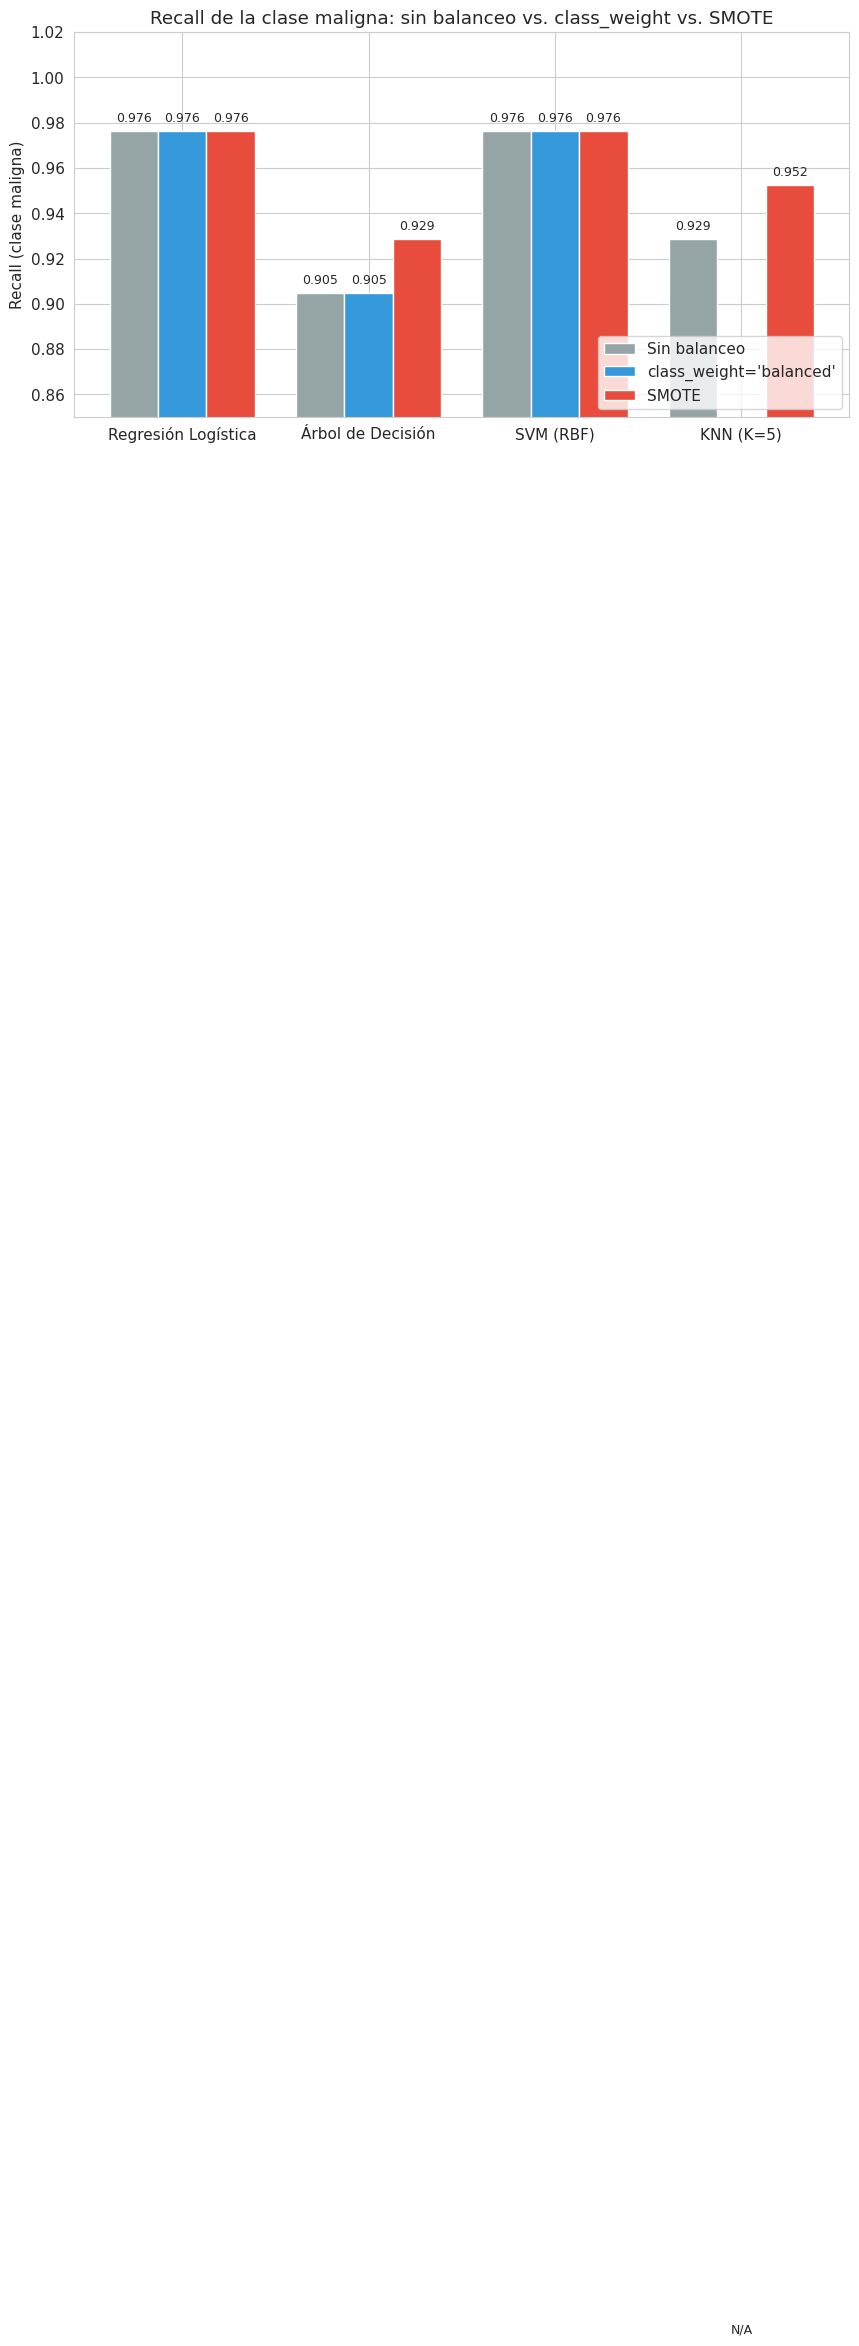

In [103]:
# Ejercicio 2 — Comparación: sin balanceo vs. class_weight vs. SMOTE (Recall de la clase maligna)
comp = pd.DataFrame({
    'Sin balanceo': {n: recall_maligno(m, X_test, y_test) for n, m in base_models.items()},
    'class_weight': {n: (recall_maligno(balanced_models[n], X_test, y_test)
                         if n in balanced_models else np.nan) for n in base_models},
    'SMOTE': {n: recall_maligno(m, X_test, y_test) for n, m in smote_models.items()}
})
comp['Δ class_weight'] = comp['class_weight'] - comp['Sin balanceo']
comp['Δ SMOTE'] = comp['SMOTE'] - comp['Sin balanceo']

fn_df = pd.DataFrame({
    'Sin balanceo': {n: fn_maligno(m, X_test, y_test) for n, m in base_models.items()},
    'class_weight': {n: (fn_maligno(balanced_models[n], X_test, y_test)
                         if n in balanced_models else np.nan) for n in base_models},
    'SMOTE': {n: fn_maligno(m, X_test, y_test) for n, m in smote_models.items()}
})

print('=== Recall de la clase maligna (Test Set, 42 casos malignos) ===')
print(comp.round(4).to_string())
print('\n=== Falsos negativos: malignos no detectados ===')
print(fn_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comp))
w = 0.26
ax.bar(x - w, comp['Sin balanceo'], w, label='Sin balanceo', color='#95a5a6')
ax.bar(x,     comp['class_weight'], w, label="class_weight='balanced'", color='#3498db')
ax.bar(x + w, comp['SMOTE'],        w, label='SMOTE', color='#e74c3c')
for xi, name in enumerate(comp.index):
    for off, col in zip((-w, 0, w), ('Sin balanceo', 'class_weight', 'SMOTE')):
        v = comp.loc[name, col]
        txt = 'N/A' if np.isnan(v) else f'{v:.3f}'
        ax.text(xi + off, (0 if np.isnan(v) else v) + 0.004, txt, ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(comp.index)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Recall (clase maligna)')
ax.set_title('Recall de la clase maligna: sin balanceo vs. class_weight vs. SMOTE')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Conclusiones del Ejercicio 2**

- **`class_weight='balanced'`:** no cambió el Recall de la clase maligna en Regresión Logística (0.9762), Árbol (0.9048) ni SVM (0.9762). El desbalance es moderado (63 %/37 %), así que reponderar las clases no modificó las predicciones sobre el test. **KNN no admite `class_weight`**, por lo que solo se evaluó con SMOTE.
- **SMOTE:** mejoró el Recall maligno del Árbol (0.9048 → 0.9286, de 4 a 3 malignos no detectados) y de KNN (0.9286 → 0.9524, de 3 a 2), y no alteró LR ni SVM (0.9762, 1 falso negativo).
- **Lectura:** el beneficio del balanceo es pequeño y se concentra en los modelos más sensibles a la distribución de clases (Árbol y KNN). Cada mejora equivale a 1 caso de 42 malignos, así que conviene confirmarla con validación cruzada antes de generalizar. SMOTE debe aplicarse solo sobre el entrenamiento, nunca sobre el test.
- **Nota:** si `imbalanced-learn` no está instalada, la celda usa una implementación propia de SMOTE con la misma lógica; con la librería original los valores pueden variar ligeramente.

---
# Solución — Ejercicio 3: Dataset propio

**Dataset:** Viral Social Media Trends (5 000 publicaciones, 8 features, clasificación multiclase)

**Objetivo:** predecir el nivel de engagement (`Low`, `Medium`, `High`) de una publicación. Se replican los 10 apartados del notebook original, aplicando los 4 modelos de la sesión + **Random Forest** como modelo adicional.

> **Nota:** esta sección redefine variables del notebook (`df`, `X_train`, `pipe_lr`, `eval_classifier`, etc.) para el nuevo dataset. Ejecútala **después** de las soluciones de los ejercicios 1 y 2 (o reinicia el entorno y ejecútala de forma independiente).

## 1. Configuración del entorno

In [104]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    roc_auc_score
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


---
## 2. Carga y exploración del dataset

El dataset **Viral Social Media Trends** contiene 5 000 publicaciones de redes sociales descritas por 4 variables categóricas (`Platform`, `Hashtag`, `Content_Type`, `Region`) y 4 numéricas (`Views`, `Likes`, `Shares`, `Comments`). El target es multiclase: nivel de engagement **bajo (Low → 0)**, **medio (Medium → 1)** o **alto (High → 2)**. `Post_ID` es solo un identificador y se descarta.

In [105]:
# Ruta del CSV (local, Colab o carpeta de subidas); si no se encuentra, en Colab se pide subirlo
csv_name = 'Viral_Social_Media_Trends.csv'
candidates = [csv_name, f'/content/{csv_name}', f'/mnt/user-data/uploads/{csv_name}']
csv_path = next((p for p in candidates if os.path.exists(p)), None)
if csv_path is None:
    from google.colab import files
    files.upload()
    csv_path = csv_name

df = pd.read_csv(csv_path)

class_names = ['Low', 'Medium', 'High']
df['target'] = df['Engagement_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})

cat_features = ['Platform', 'Hashtag', 'Content_Type', 'Region']
num_features = ['Views', 'Likes', 'Shares', 'Comments']
feature_names = cat_features + num_features

print(f'Dataset: {df.shape[0]} muestras, {len(feature_names)} features '
      f'({len(cat_features)} categóricas + {len(num_features)} numéricas)')
print(f'Valores nulos: {int(df[feature_names + ["target"]].isna().sum().sum())}  |  '
      f'IDs duplicados: {int(df["Post_ID"].duplicated().sum())}')
print(f'\nDistribución de clases:')
print(df['Engagement_Level'].value_counts().reindex(class_names))
print(f'\nProporción: ' + ', '.join(
    f'{p:.1%} {c}' for c, p in df['Engagement_Level'].value_counts(normalize=True).reindex(class_names).items()))

Dataset: 5000 muestras, 8 features (4 categóricas + 4 numéricas)
Valores nulos: 0  |  IDs duplicados: 0

Distribución de clases:
Engagement_Level
Low       1729
Medium    1598
High      1673
Name: count, dtype: int64

Proporción: 34.6% Low, 32.0% Medium, 33.5% High


In [106]:
df[num_features].describe().round(3)

,Views,Likes,Shares,Comments
count,5000.000,5000.000,5000.000,5000.000
mean,2494066.444,251475.030,50519.562,24888.394
std,1459489.824,144349.583,29066.363,14284.504
min,1266.000,490.000,52.000,18.000
25%,1186207.250,126892.250,25029.000,12305.250
50%,2497373.000,249443.000,50839.500,25004.000
75%,3759781.000,373970.750,75774.250,37072.750
max,4999430.000,499922.000,99978.000,49993.000


---
## 3. Análisis exploratorio orientado a clasificación

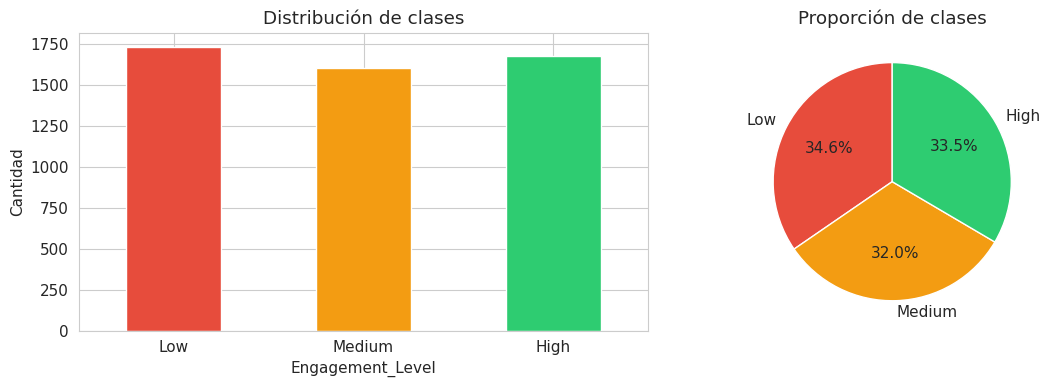

In [107]:
# 3.1  Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
colors = ['#e74c3c', '#f39c12', '#2ecc71']   # Low, Medium, High
counts = df['Engagement_Level'].value_counts().reindex(class_names)
counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(class_names, rotation=0)

# Pie chart
counts.plot(kind='pie', ax=axes[1], colors=colors,
    autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

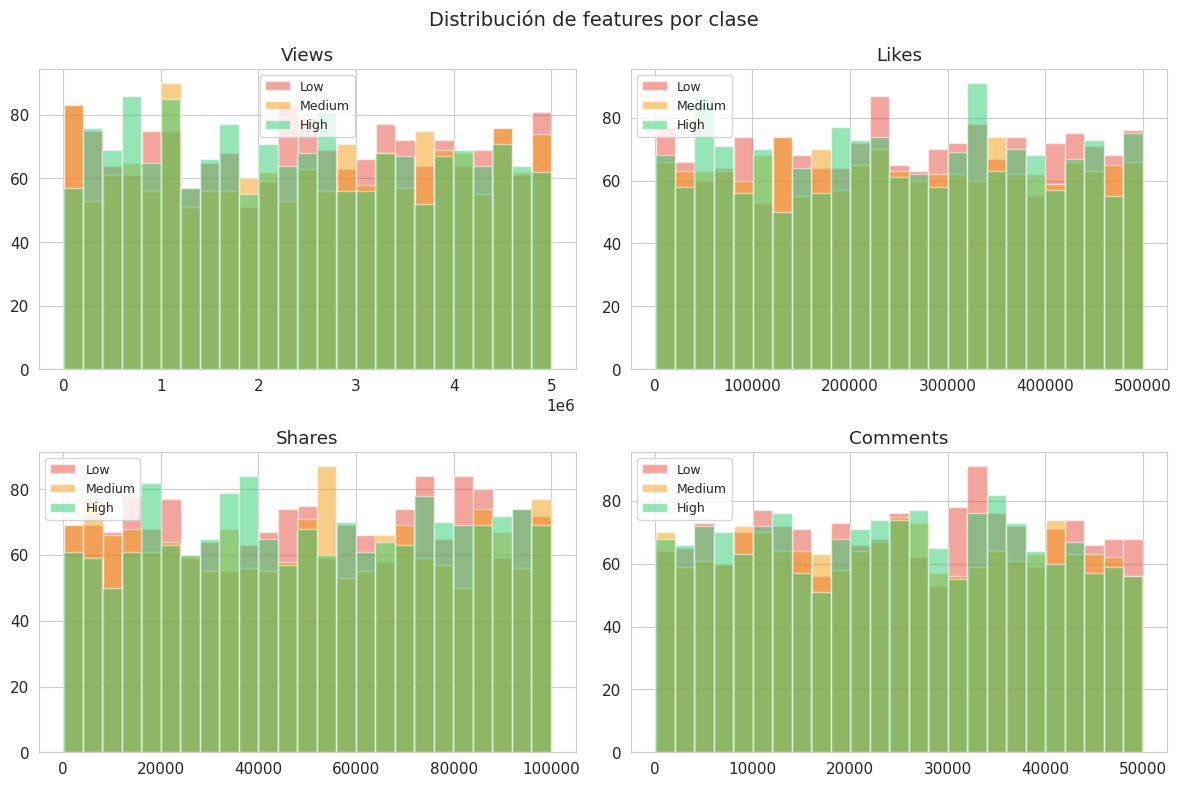

In [108]:
# 3.2  Distribución de features clave por clase
key_features = num_features   # las 4 features numéricas

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, feat in enumerate(key_features):
    ax = axes[i//2, i%2]
    for label, color in zip([0, 1, 2], colors):
        subset = df[df['target'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.5, color=color,
                label=class_names[label])
    ax.set_title(feat)
    ax.legend(fontsize=9)

plt.suptitle('Distribución de features por clase', fontsize=14)
plt.tight_layout()
plt.show()

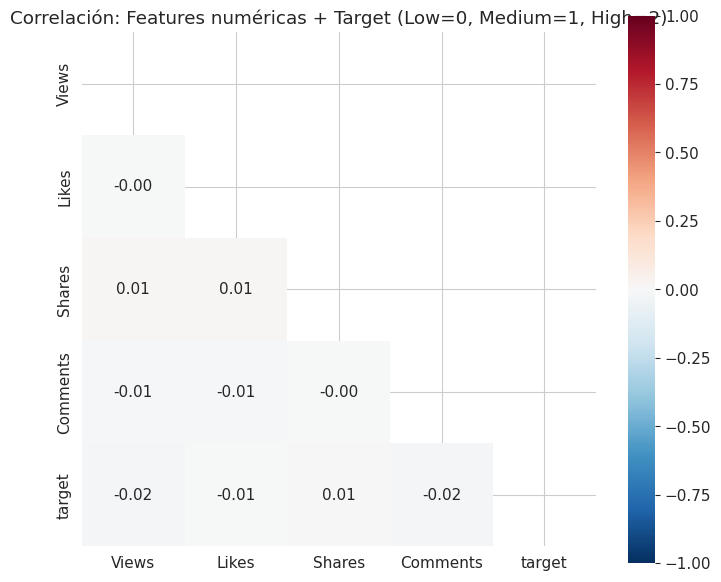

In [109]:
# 3.3  Matriz de correlación (features numéricas + Target)
plt.figure(figsize=(7, 6))
corr = df[num_features + ['target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlación: Features numéricas + Target (Low=0, Medium=1, High=2)')
plt.tight_layout()
plt.show()

F de ANOVA por feature numérica:
Views       1.400
Shares      1.207
Comments    0.716
Likes       0.308


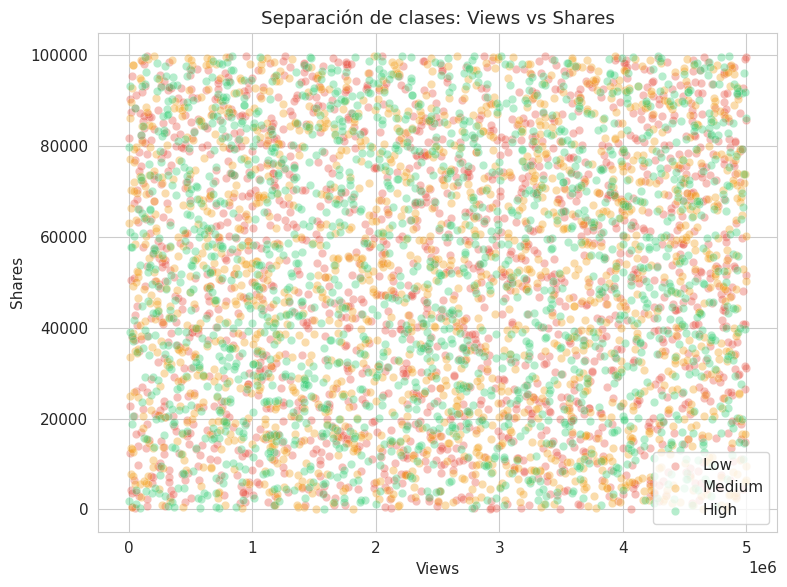

In [110]:
# 3.4  Scatter plot: 2 features más discriminativas (mayor F de ANOVA respecto al target)
f_vals, _ = f_classif(df[num_features], df['target'])
ranking = pd.Series(f_vals, index=num_features).sort_values(ascending=False)
top2 = ranking.index[:2].tolist()
print('F de ANOVA por feature numérica:')
print(ranking.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1, 2], colors, class_names):
    mask = df['target'] == label
    ax.scatter(df.loc[mask, top2[0]], df.loc[mask, top2[1]],
              alpha=0.35, c=color, label=name, edgecolors='w', linewidth=0.3)
ax.set_xlabel(top2[0])
ax.set_ylabel(top2[1])
ax.set_title(f'Separación de clases: {top2[0]} vs {top2[1]}')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [111]:
X = df[feature_names].copy()
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Test:          {X_test.shape[0]} muestras')
print('\nProporción en train: ' + ', '.join(
    f'{y_train.eq(i).mean():.1%} {n}' for i, n in enumerate(class_names)))
print('Proporción en test:  ' + ', '.join(
    f'{y_test.eq(i).mean():.1%} {n}' for i, n in enumerate(class_names)))

# Stratified K-Fold para validación cruzada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Preprocesamiento: estandarizar numéricas + one-hot para categóricas
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])
# Para modelos basados en árboles no hace falta estandarizar
preprocess_tree = ColumnTransformer([
    ('num', 'passthrough', num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

Entrenamiento: 4000 muestras
Test:          1000 muestras

Proporción en train: 34.6% Low, 31.9% Medium, 33.5% High
Proporción en test:  34.6% Low, 32.0% Medium, 33.4% High


### Funciones auxiliares para evaluación de clasificadores

In [112]:
def get_scores(model, X_te):
    """Score por clase (probabilidad o función de decisión), forma (n, n_clases)."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_te)
    return model.decision_function(X_te)


def eval_classifier(model, X_tr, y_tr, X_te, y_te, model_name='Modelo'):
    """Evalúa un clasificador multiclase: métricas macro, matriz de confusión y reporte."""
    y_pred = model.predict(X_te)

    metrics = {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, average='macro', zero_division=0),
        'Recall':    recall_score(y_te, y_pred, average='macro'),
        'F1-Score':  f1_score(y_te, y_pred, average='macro')
    }

    print(f'=== {model_name} ===')
    for k, v in metrics.items():
        print(f'  {k} (macro): {v:.4f}' if k != 'Accuracy' else f'  {k}: {v:.4f}')

    # Matriz de confusión
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0].set_title(f'Matriz de Confusión — {model_name}')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')

    # Desglose de aciertos y errores (FN) por clase
    aciertos = np.diag(cm)
    fn = cm.sum(axis=1) - aciertos
    fp = cm.sum(axis=0) - aciertos
    xpos = np.arange(len(class_names))
    w = 0.27
    axes[1].bar(xpos - w, aciertos, w, color='#2ecc71', label='Aciertos (TP)')
    axes[1].bar(xpos,     fn,       w, color='#e74c3c', label='FN (clase real mal clasificada)')
    axes[1].bar(xpos + w, fp,       w, color='#f39c12', label='FP (otras clases asignadas)')
    axes[1].set_xticks(xpos)
    axes[1].set_xticklabels(class_names)
    axes[1].set_title(f'Desglose por clase — {model_name}')
    axes[1].set_ylabel('Cantidad')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    for i, n in enumerate(class_names):
        print(f'  {n:7s} -> TP: {aciertos[i]:3d} | FN: {fn[i]:3d} | FP: {fp[i]:3d}')
    print(f'\nReporte completo:')
    print(classification_report(y_te, y_pred, target_names=class_names))

    return metrics


def plot_roc(model, X_te, y_te, model_name='Modelo', ax=None):
    """Curvas ROC One-vs-Rest (una por clase). Devuelve el AUC macro."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    y_score = get_scores(model, X_te)
    y_bin = label_binarize(y_te, classes=[0, 1, 2])

    for i, (n, c) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        ax.plot(fpr, tpr, linewidth=2, color=c,
                label=f'{n} vs resto (AUC = {auc(fpr, tpr):.4f})')

    auc_macro = roc_auc_score(y_bin, y_score, average='macro')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC = 0.5)')
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'Curva ROC — {model_name}\n(AUC macro = {auc_macro:.4f})')
    ax.legend(fontsize=8)

    return auc_macro


def roc_macro_curve(model, X_te, y_te):
    """Curva ROC promedio macro (OvR) para superponer varios modelos."""
    y_score = get_scores(model, X_te)
    y_bin = label_binarize(y_te, classes=[0, 1, 2])
    grid = np.linspace(0, 1, 200)
    tprs = []
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        tprs.append(np.interp(grid, fpr, tpr))
    return grid, np.mean(tprs, axis=0), roc_auc_score(y_bin, y_score, average='macro')

---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima P(y=k|x) mediante la función sigmoide (softmax en el caso multiclase). La frontera de decisión es lineal en el espacio de features. Se optimiza minimizando la Log-Loss (entropía cruzada) con regularización L2 por defecto.

In [113]:
# 5.1  Pipeline con preprocesamiento (estandarización + one-hot)
pipe_lr = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Validación cruzada estratificada
scoring_cv = ['accuracy', 'f1_macro', 'recall_macro']
cv_lr = cross_validate(pipe_lr, X_train, y_train, cv=skf,
                       scoring=scoring_cv, return_train_score=True)

print('Regresión Logística — Cross-Validation (5-fold)')
print(f'  Accuracy:  {cv_lr["test_accuracy"].mean():.4f} ± {cv_lr["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_lr["test_f1_macro"].mean():.4f} ± {cv_lr["test_f1_macro"].std():.4f}')
print(f'  Recall:    {cv_lr["test_recall_macro"].mean():.4f} ± {cv_lr["test_recall_macro"].std():.4f}')

# Entrenar modelo final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Regresión Logística — Cross-Validation (5-fold)
  Accuracy:  0.3230 ± 0.0110
  F1-Score:  0.3177 ± 0.0105
  Recall:    0.3209 ± 0.0108


=== Regresión Logística ===
  Accuracy: 0.3350
  Precision (macro): 0.3325
  Recall (macro): 0.3330
  F1-Score (macro): 0.3300


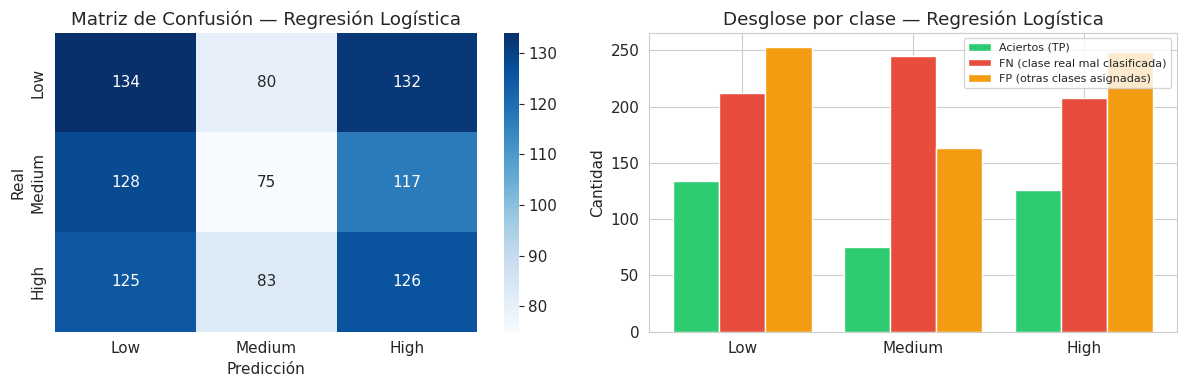

  Low     -> TP: 134 | FN: 212 | FP: 253
  Medium  -> TP:  75 | FN: 245 | FP: 163
  High    -> TP: 126 | FN: 208 | FP: 249

Reporte completo:
              precision    recall  f1-score   support

         Low       0.35      0.39      0.37       346
      Medium       0.32      0.23      0.27       320
        High       0.34      0.38      0.36       334

    accuracy                           0.34      1000
   macro avg       0.33      0.33      0.33      1000
weighted avg       0.33      0.34      0.33      1000



In [114]:
# 5.2  Evaluación completa
metrics_lr = eval_classifier(pipe_lr, X_train, y_train, X_test, y_test,
                             'Regresión Logística')

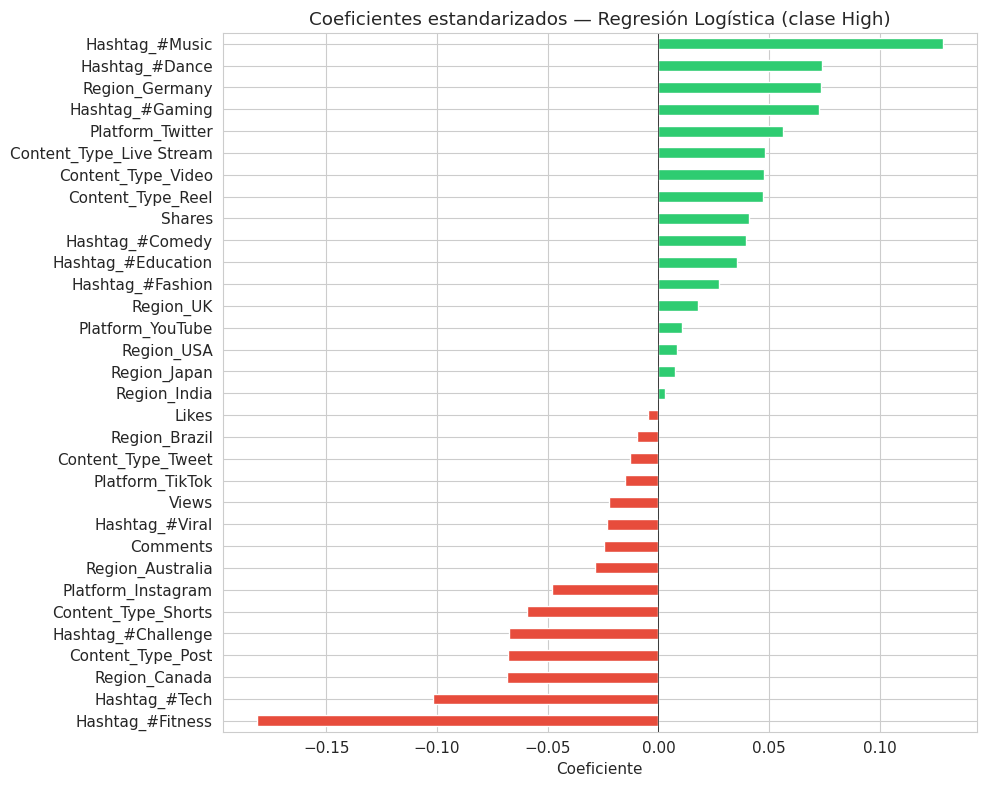

Interpretación:
  → Features que más indican engagement BAJO/MEDIO (coef. más negativo): ['Hashtag_#Fitness', 'Hashtag_#Tech', 'Region_Canada']
  → Features que más indican engagement ALTO (coef. más positivo): ['Region_Germany', 'Hashtag_#Dance', 'Hashtag_#Music']


In [115]:
# 5.3  Coeficientes estandarizados (clase High vs. resto)
feat_names_out = pipe_lr.named_steps['prep'].get_feature_names_out()
feat_names_out = [n.split('__', 1)[1] for n in feat_names_out]
idx_high = list(pipe_lr.named_steps['clf'].classes_).index(2)

coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[idx_high],
    index=feat_names_out
).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs]
coefs.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('Coeficientes estandarizados — Regresión Logística (clase High)')
ax.set_xlabel('Coeficiente')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'  → Features que más indican engagement BAJO/MEDIO (coef. más negativo): {coefs.head(3).index.tolist()}')
print(f'  → Features que más indican engagement ALTO (coef. más positivo): {coefs.tail(3).index.tolist()}')

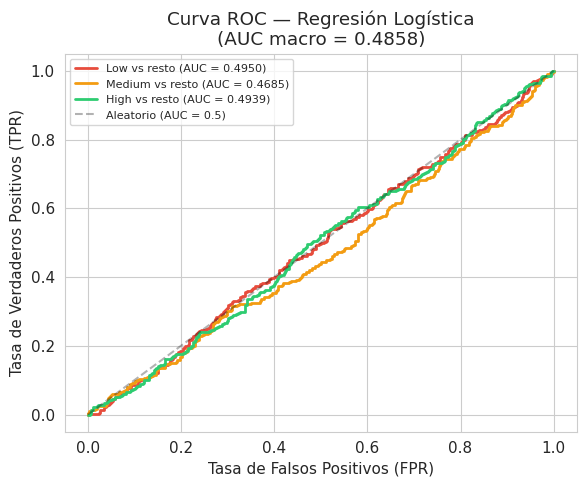

AUC (macro, OvR): 0.4858


In [116]:
# 5.4  Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
auc_lr = plot_roc(pipe_lr, X_test, y_test, 'Regresión Logística', ax)
plt.tight_layout()
plt.show()
print(f'AUC (macro, OvR): {auc_lr:.4f}')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** CART construye particiones recursivas del espacio de features. En cada nodo selecciona la feature y el umbral que maximizan la reducción de impureza (Gini: G(t) = 1 − Σpₖ²). Las particiones son ortogonales a los ejes.

In [117]:
# 6.1  Árbol sin restricciones (para mostrar sobreajuste)
pipe_dt_full = Pipeline([
    ('prep', preprocess_tree),
    ('clf', DecisionTreeClassifier(random_state=42))
])

cv_dt_full = cross_validate(pipe_dt_full, X_train, y_train, cv=skf,
                            scoring=scoring_cv, return_train_score=True)

print('Árbol de Decisión (SIN restricciones) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt_full["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt_full["test_accuracy"].mean():.4f} ± {cv_dt_full["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt_full["test_f1_macro"].mean():.4f} ± {cv_dt_full["test_f1_macro"].std():.4f}')
print(f'\n⚠ Train accuracy ~1.0 indica sobreajuste')

Árbol de Decisión (SIN restricciones) — CV 5-fold
  Train Accuracy: 1.0000
  Test Accuracy:  0.3260 ± 0.0169
  Test F1-Score:  0.3253 ± 0.0174

⚠ Train accuracy ~1.0 indica sobreajuste


In [118]:
# 6.2  Árbol con pre-poda
pipe_dt = Pipeline([
    ('prep', preprocess_tree),
    ('clf', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

cv_dt = cross_validate(pipe_dt, X_train, y_train, cv=skf,
                       scoring=scoring_cv, return_train_score=True)

print('Árbol de Decisión (con pre-poda) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt["test_accuracy"].mean():.4f} ± {cv_dt["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt["test_f1_macro"].mean():.4f} ± {cv_dt["test_f1_macro"].std():.4f}')
print(f'  Test Recall:    {cv_dt["test_recall_macro"].mean():.4f} ± {cv_dt["test_recall_macro"].std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Árbol de Decisión (con pre-poda) — CV 5-fold
  Train Accuracy: 0.3896
  Test Accuracy:  0.3390 ± 0.0131
  Test F1-Score:  0.2870 ± 0.0174
  Test Recall:    0.3376 ± 0.0130


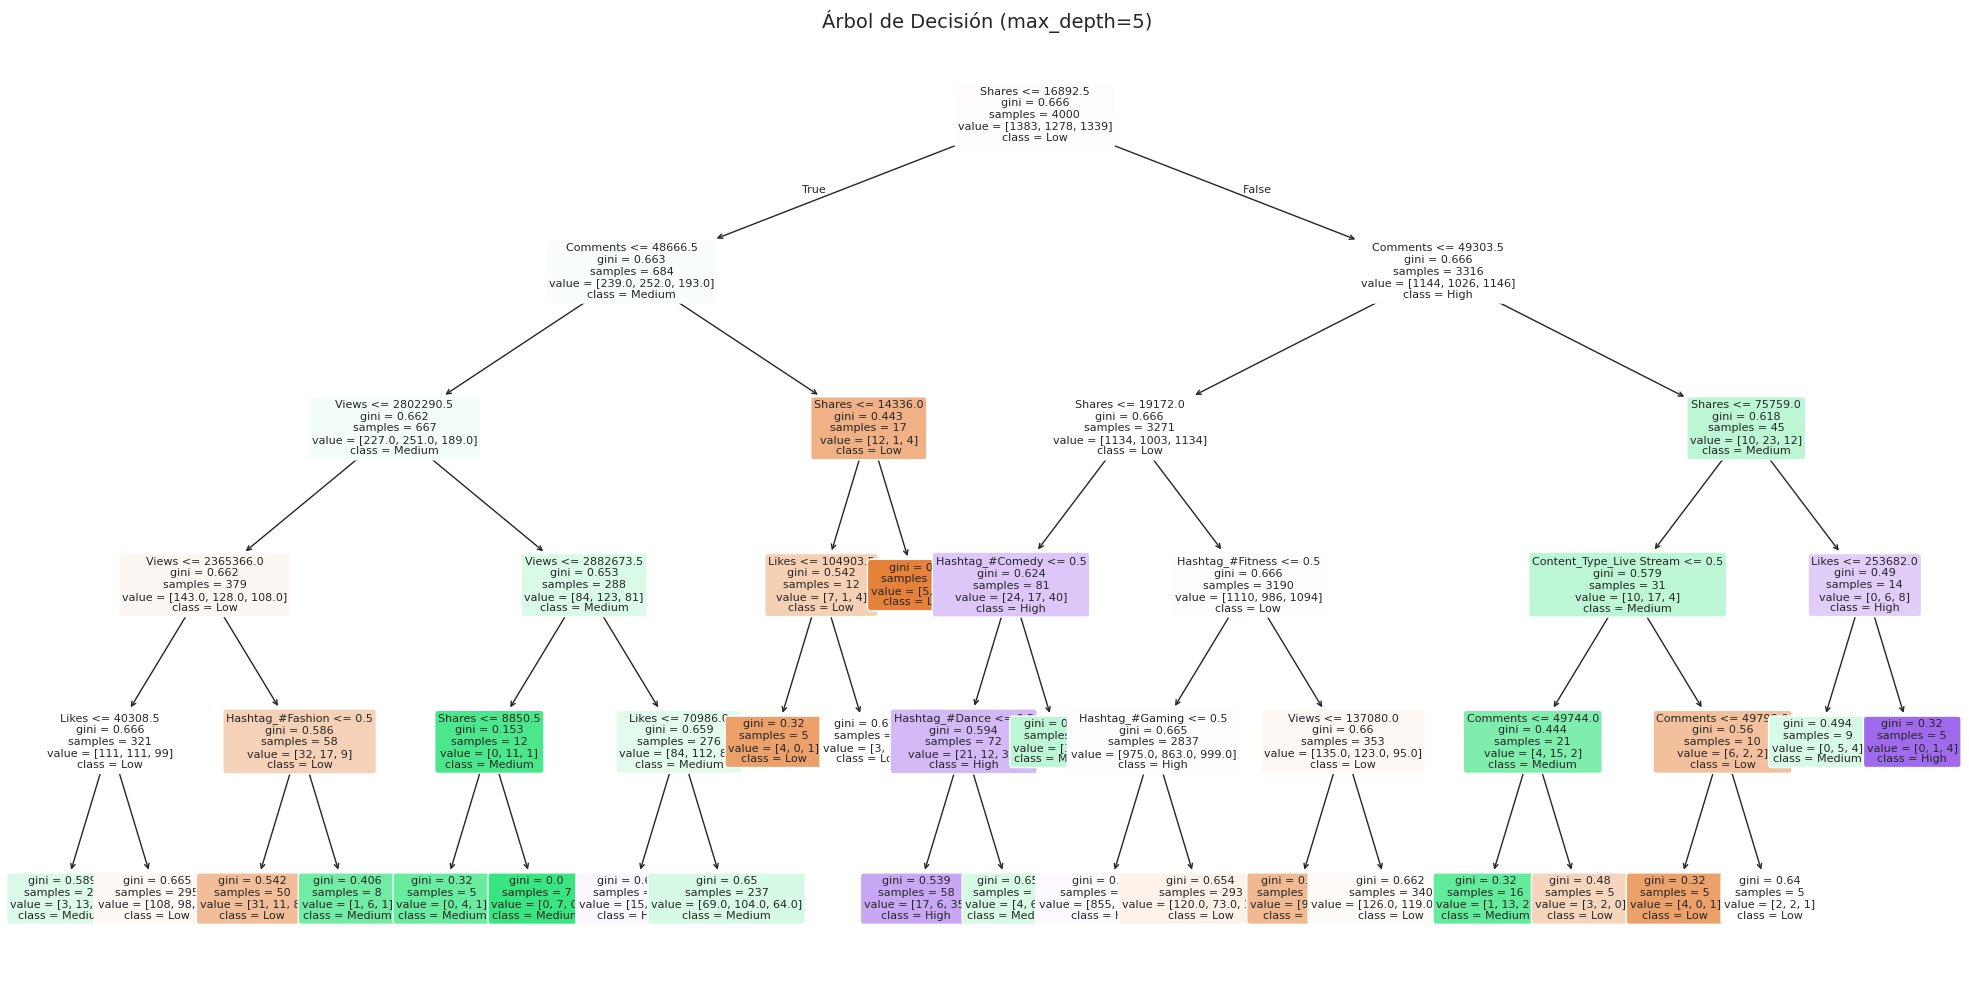

In [119]:
# 6.3  Visualización del árbol podado
tree_feat_names = [n.split('__', 1)[1] for n in pipe_dt.named_steps['prep'].get_feature_names_out()]

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(pipe_dt.named_steps['clf'],
          feature_names=tree_feat_names,
          class_names=class_names,
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Árbol de Decisión (max_depth=5)', fontsize=14)
plt.tight_layout()
plt.show()

=== Árbol de Decisión ===
  Accuracy: 0.3510
  Precision (macro): 0.3624
  Recall (macro): 0.3482
  F1-Score (macro): 0.3041


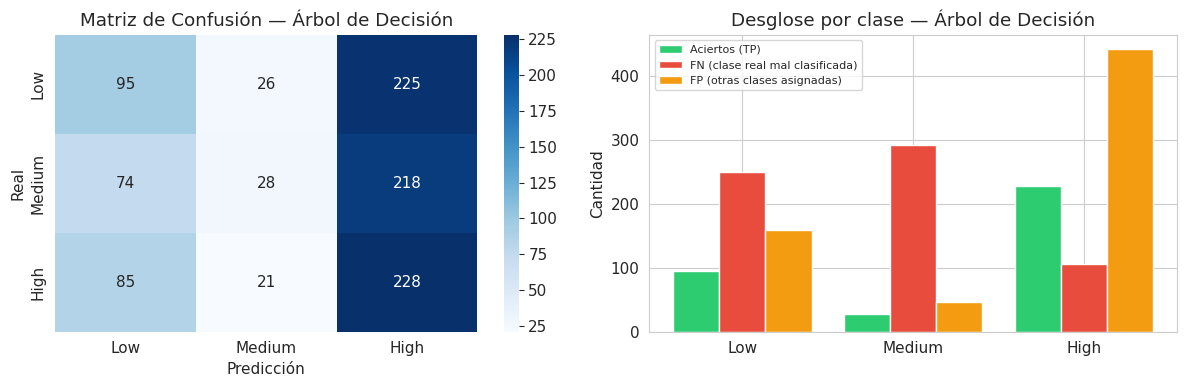

  Low     -> TP:  95 | FN: 251 | FP: 159
  Medium  -> TP:  28 | FN: 292 | FP:  47
  High    -> TP: 228 | FN: 106 | FP: 443

Reporte completo:
              precision    recall  f1-score   support

         Low       0.37      0.27      0.32       346
      Medium       0.37      0.09      0.14       320
        High       0.34      0.68      0.45       334

    accuracy                           0.35      1000
   macro avg       0.36      0.35      0.30      1000
weighted avg       0.36      0.35      0.31      1000



In [120]:
# 6.4  Evaluación completa
metrics_dt = eval_classifier(pipe_dt, X_train, y_train, X_test, y_test,
                             'Árbol de Decisión')

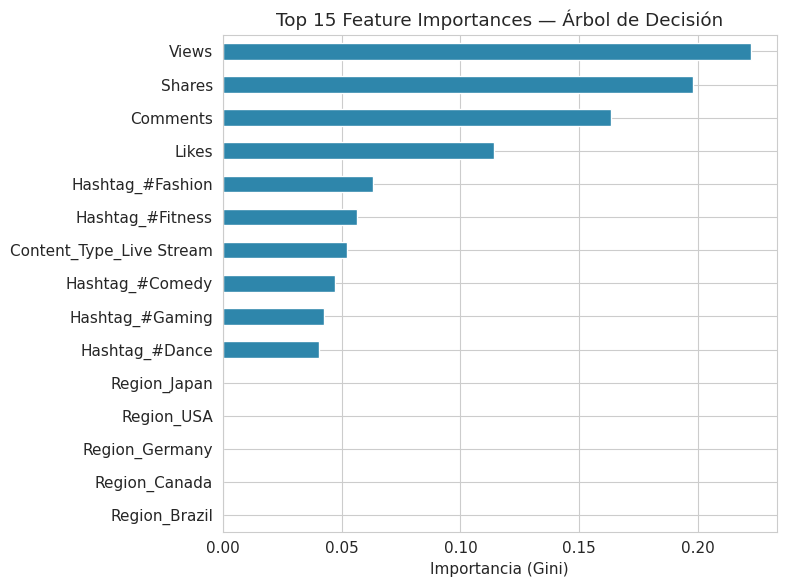

In [121]:
# 6.5  Importancia de features
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=tree_feat_names
).sort_values(ascending=True)

# Top 15
top_imp = importances.tail(15)
fig, ax = plt.subplots(figsize=(8, 6))
top_imp.plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Top 15 Feature Importances — Árbol de Decisión')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

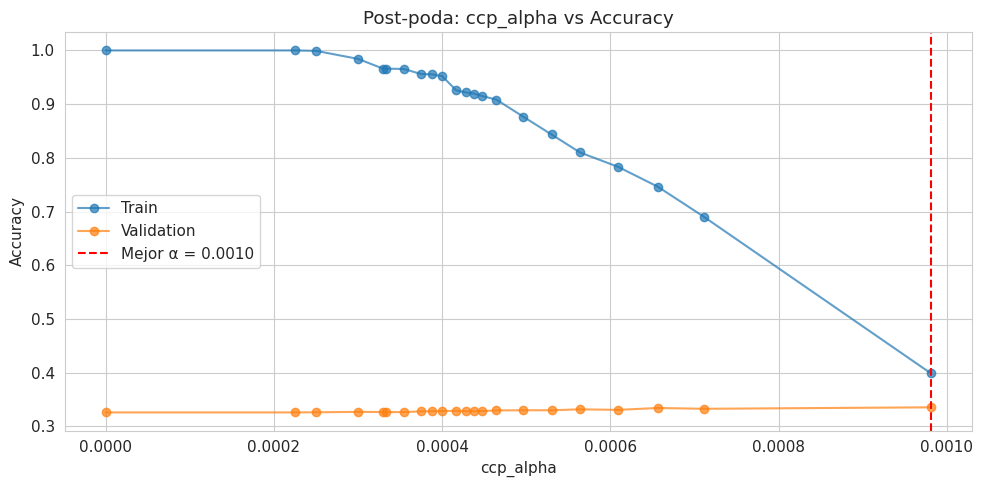

Mejor ccp_alpha: 0.000981


In [122]:
# 6.6  Post-poda con ccp_alpha
X_train_tree = preprocess_tree.fit_transform(X_train)   # solo one-hot + passthrough (sin fuga de información)
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train_tree, y_train)
alphas = path.ccp_alphas[:-1]  # excluir el último (árbol trivial)

# Con 4 000 muestras el camino de poda tiene cientos de α: se evalúa una rejilla representativa
alphas = np.unique(np.quantile(alphas, np.linspace(0, 1, 25)))

train_scores, test_scores = [], []
for alpha in alphas:
    dt_temp = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    cv_temp = cross_validate(dt_temp, X_train_tree, y_train, cv=skf,
                             scoring='accuracy', return_train_score=True)
    train_scores.append(cv_temp['train_score'].mean())
    test_scores.append(cv_temp['test_score'].mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, train_scores, 'o-', label='Train', alpha=0.7)
ax.plot(alphas, test_scores, 'o-', label='Validation', alpha=0.7)
best_idx = np.argmax(test_scores)
ax.axvline(x=alphas[best_idx], color='red', linestyle='--',
           label=f'Mejor α = {alphas[best_idx]:.4f}')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Accuracy')
ax.set_title('Post-poda: ccp_alpha vs Accuracy')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mejor ccp_alpha: {alphas[best_idx]:.6f}')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** SVM busca el hiperplano de máximo margen γ = 2/‖w‖ que separa las clases. Con margen suave, permite violaciones controladas: min ½‖w‖² + C·Σξᵢ. El kernel trick transforma el espacio para manejar no linealidad.

In [123]:
# 7.1  Pipeline SVM con kernel RBF
pipe_svm = Pipeline([
    ('prep', preprocess),
    ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
])

cv_svm = cross_validate(pipe_svm, X_train, y_train, cv=skf,
                        scoring=scoring_cv, return_train_score=True)

print('SVM (RBF, C=1.0) — CV 5-fold')
print(f'  Accuracy:  {cv_svm["test_accuracy"].mean():.4f} ± {cv_svm["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_svm["test_f1_macro"].mean():.4f} ± {cv_svm["test_f1_macro"].std():.4f}')
print(f'  Recall:    {cv_svm["test_recall_macro"].mean():.4f} ± {cv_svm["test_recall_macro"].std():.4f}')

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)

SVM (RBF, C=1.0) — CV 5-fold
  Accuracy:  0.3190 ± 0.0114
  F1-Score:  0.3159 ± 0.0103
  Recall:    0.3174 ± 0.0109


=== SVM (RBF) ===
  Accuracy: 0.3300
  Precision (macro): 0.3279
  Recall (macro): 0.3282
  F1-Score (macro): 0.3266


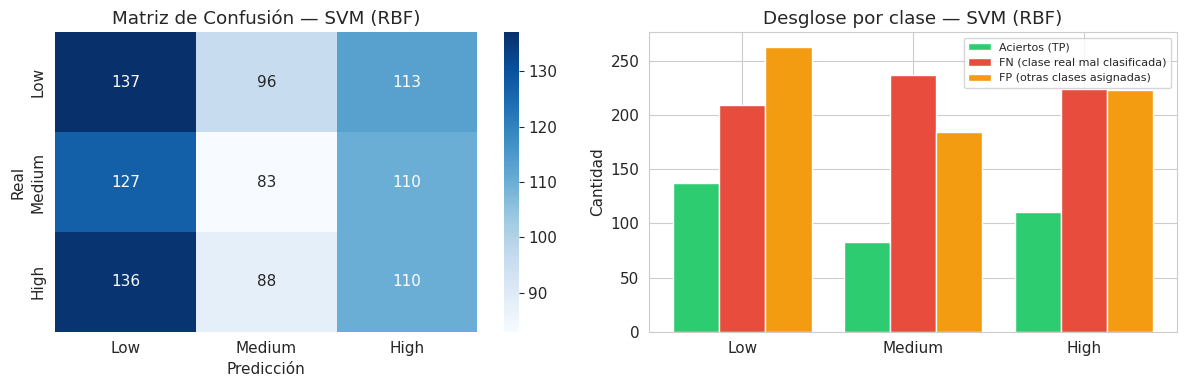

  Low     -> TP: 137 | FN: 209 | FP: 263
  Medium  -> TP:  83 | FN: 237 | FP: 184
  High    -> TP: 110 | FN: 224 | FP: 223

Reporte completo:
              precision    recall  f1-score   support

         Low       0.34      0.40      0.37       346
      Medium       0.31      0.26      0.28       320
        High       0.33      0.33      0.33       334

    accuracy                           0.33      1000
   macro avg       0.33      0.33      0.33      1000
weighted avg       0.33      0.33      0.33      1000



In [124]:
# 7.2  Evaluación completa
metrics_svm = eval_classifier(pipe_svm, X_train, y_train, X_test, y_test, 'SVM (RBF)')

  Kernel linear  : Accuracy = 0.3335
  Kernel rbf     : Accuracy = 0.3190
  Kernel poly    : Accuracy = 0.3180


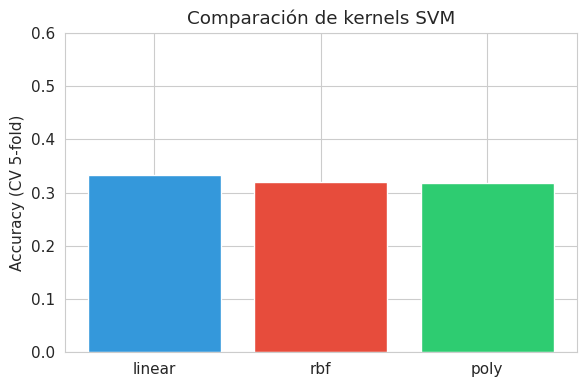

In [125]:
# 7.3  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
kernel_results = {}

for k in kernels:
    pipe_k = Pipeline([
        ('prep', preprocess),
        ('clf', SVC(kernel=k, C=1.0, random_state=42))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring='accuracy')
    kernel_results[k] = cv_k['test_score'].mean()
    print(f'  Kernel {k:8s}: Accuracy = {kernel_results[k]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(kernel_results.keys(), kernel_results.values(), color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Comparación de kernels SVM')
ax.set_ylim(0.0, 0.6)
plt.tight_layout()
plt.show()

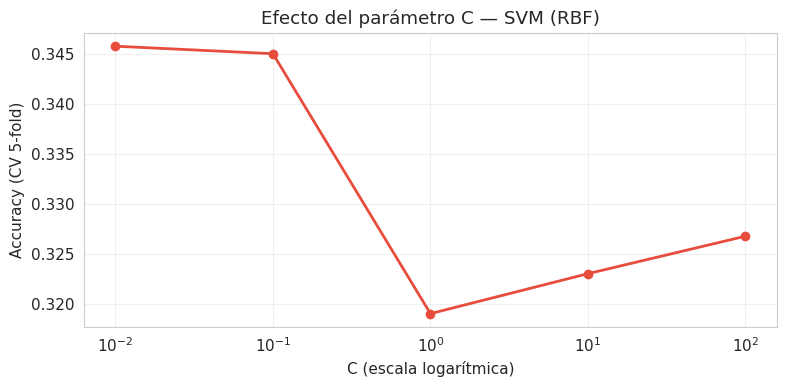


Interpretación:
  C bajo → margen amplio, más errores permitidos (mayor sesgo)
  C alto → margen estrecho, menos errores permitidos (mayor varianza)


In [126]:
# 7.4  Efecto del parámetro C
C_values = [0.01, 0.1, 1, 10, 100]
c_scores = []

for c in C_values:
    pipe_c = Pipeline([
        ('prep', preprocess),
        ('clf', SVC(kernel='rbf', C=c, random_state=42))
    ])
    cv_c = cross_validate(pipe_c, X_train, y_train, cv=skf, scoring='accuracy')
    c_scores.append(cv_c['test_score'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_values, c_scores, 'o-', color='#e74c3c', linewidth=2)
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Efecto del parámetro C — SVM (RBF)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nInterpretación:')
print('  C bajo → margen amplio, más errores permitidos (mayor sesgo)')
print('  C alto → margen estrecho, menos errores permitidos (mayor varianza)')

---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Algoritmo de aprendizaje basado en instancias (lazy learning). No construye un modelo explícito; clasifica por voto mayoritario de los K vecinos más cercanos según distancia Euclidiana (por defecto). La regla empírica sugiere K ≈ √n.

In [127]:
# 8.1  Pipeline KNN
pipe_knn = Pipeline([
    ('prep', preprocess),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

cv_knn = cross_validate(pipe_knn, X_train, y_train, cv=skf,
                        scoring=scoring_cv, return_train_score=True)

print('KNN (K=5) — CV 5-fold')
print(f'  Accuracy:  {cv_knn["test_accuracy"].mean():.4f} ± {cv_knn["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_knn["test_f1_macro"].mean():.4f} ± {cv_knn["test_f1_macro"].std():.4f}')
print(f'  Recall:    {cv_knn["test_recall_macro"].mean():.4f} ± {cv_knn["test_recall_macro"].std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=5) — CV 5-fold
  Accuracy:  0.3282 ± 0.0124
  F1-Score:  0.3185 ± 0.0100
  Recall:    0.3260 ± 0.0124


=== KNN (K=5) ===
  Accuracy: 0.3460
  Precision (macro): 0.3447
  Recall (macro): 0.3433
  F1-Score (macro): 0.3341


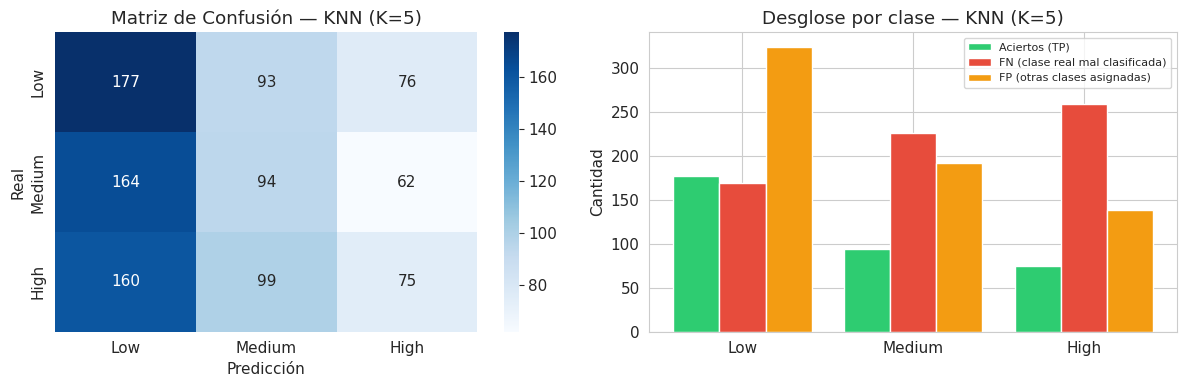

  Low     -> TP: 177 | FN: 169 | FP: 324
  Medium  -> TP:  94 | FN: 226 | FP: 192
  High    -> TP:  75 | FN: 259 | FP: 138

Reporte completo:
              precision    recall  f1-score   support

         Low       0.35      0.51      0.42       346
      Medium       0.33      0.29      0.31       320
        High       0.35      0.22      0.27       334

    accuracy                           0.35      1000
   macro avg       0.34      0.34      0.33      1000
weighted avg       0.35      0.35      0.34      1000



In [128]:
# 8.2  Evaluación completa
metrics_knn = eval_classifier(pipe_knn, X_train, y_train, X_test, y_test, 'KNN (K=5)')

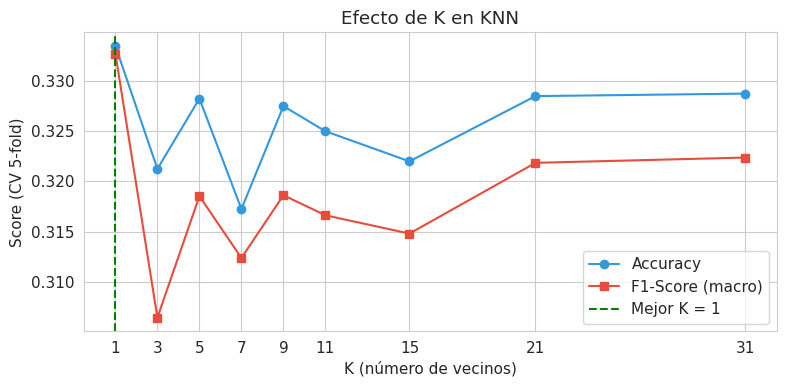

Mejor K por F1: 1
K empírico (√4000): 63


In [129]:
# 8.3  Búsqueda del K óptimo
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_scores_acc = []
k_scores_f1 = []

for k in k_values:
    pipe_k = Pipeline([
        ('prep', preprocess),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring=['accuracy', 'f1_macro'])
    k_scores_acc.append(cv_k['test_accuracy'].mean())
    k_scores_f1.append(cv_k['test_f1_macro'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, k_scores_acc, 'o-', label='Accuracy', color='#3498db')
ax.plot(k_values, k_scores_f1, 's-', label='F1-Score (macro)', color='#e74c3c')
best_k = k_values[np.argmax(k_scores_f1)]
ax.axvline(x=best_k, color='green', linestyle='--', label=f'Mejor K = {best_k}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('Score (CV 5-fold)')
ax.set_title('Efecto de K en KNN')
ax.legend()
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

print(f'Mejor K por F1: {best_k}')
print(f'K empírico (√{len(X_train)}): {int(np.sqrt(len(X_train)))}')

In [130]:
# 8.4  Comparación de métricas de distancia
distances = ['euclidean', 'manhattan', 'minkowski']
dist_results = {}

for d in distances:
    p_val = 3 if d == 'minkowski' else 2
    pipe_d = Pipeline([
        ('prep', preprocess),
        ('clf', KNeighborsClassifier(n_neighbors=5, metric=d, p=p_val))
    ])
    cv_d = cross_validate(pipe_d, X_train, y_train, cv=skf, scoring='f1_macro')
    dist_results[d] = cv_d['test_score'].mean()
    label = f'{d} (p={p_val})' if d == 'minkowski' else d
    print(f'  Distancia {label:20s}: F1 (macro) = {dist_results[d]:.4f}')

  Distancia euclidean           : F1 (macro) = 0.3185
  Distancia manhattan           : F1 (macro) = 0.3184
  Distancia minkowski (p=3)     : F1 (macro) = 0.3138


---
## 9. Comparación final de modelos

### Modelo adicional — Random Forest

**Fundamento:** Ensamble de árboles de decisión entrenados sobre muestras bootstrap y con subconjuntos aleatorios de features en cada división (bagging). La predicción es el voto mayoritario de los árboles, lo que reduce la varianza y el sobreajuste de un árbol individual.

Random Forest (300 árboles) — CV 5-fold
  Train Accuracy: 0.9639
  Accuracy:  0.3220 ± 0.0132
  F1-Score:  0.3175 ± 0.0126
  Recall:    0.3200 ± 0.0130
=== Random Forest ===
  Accuracy: 0.3530
  Precision (macro): 0.3507
  Recall (macro): 0.3508
  F1-Score (macro): 0.3480


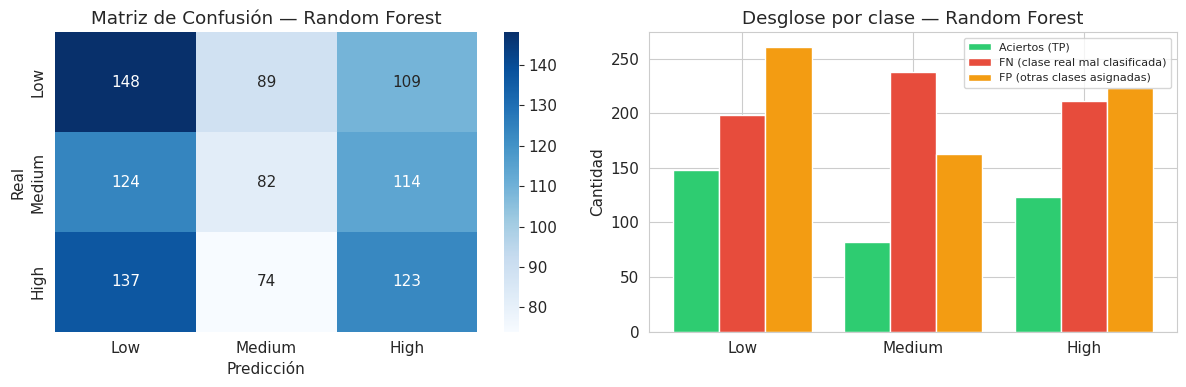

  Low     -> TP: 148 | FN: 198 | FP: 261
  Medium  -> TP:  82 | FN: 238 | FP: 163
  High    -> TP: 123 | FN: 211 | FP: 223

Reporte completo:
              precision    recall  f1-score   support

         Low       0.36      0.43      0.39       346
      Medium       0.33      0.26      0.29       320
        High       0.36      0.37      0.36       334

    accuracy                           0.35      1000
   macro avg       0.35      0.35      0.35      1000
weighted avg       0.35      0.35      0.35      1000



In [131]:
# Random Forest (modelo adicional del Ejercicio 3)
pipe_rf = Pipeline([
    ('prep', preprocess_tree),
    ('clf', RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                   random_state=42, n_jobs=-1))
])

cv_rf = cross_validate(pipe_rf, X_train, y_train, cv=skf,
                       scoring=scoring_cv, return_train_score=True)

print('Random Forest (300 árboles) — CV 5-fold')
print(f'  Train Accuracy: {cv_rf["train_accuracy"].mean():.4f}')
print(f'  Accuracy:  {cv_rf["test_accuracy"].mean():.4f} ± {cv_rf["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_rf["test_f1_macro"].mean():.4f} ± {cv_rf["test_f1_macro"].std():.4f}')
print(f'  Recall:    {cv_rf["test_recall_macro"].mean():.4f} ± {cv_rf["test_recall_macro"].std():.4f}')

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

metrics_rf = eval_classifier(pipe_rf, X_train, y_train, X_test, y_test, 'Random Forest')

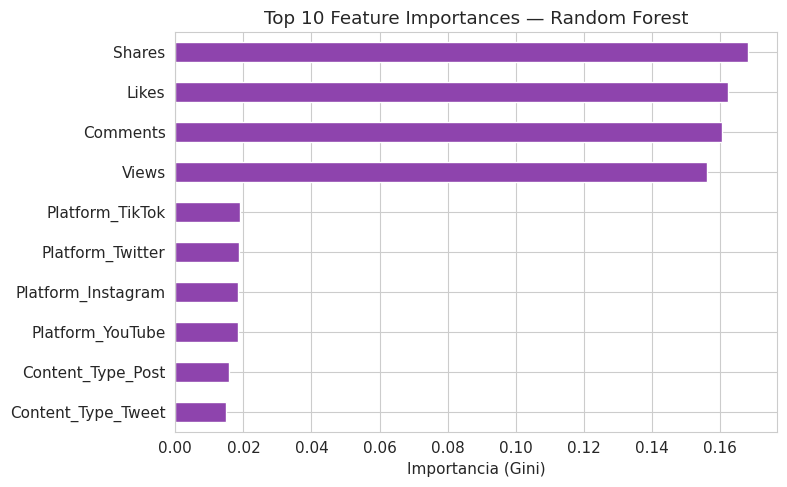

In [132]:
# Importancia de features — Random Forest
rf_imp = pd.Series(
    pipe_rf.named_steps['clf'].feature_importances_,
    index=tree_feat_names
).sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(8, 5))
rf_imp.plot(kind='barh', ax=ax, color='#8e44ad')
ax.set_title('Top 10 Feature Importances — Random Forest')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

In [133]:
# 9.1  Tabla resumen de métricas (macro-promedio en multiclase)
all_models = {
    'Regresión Logística': pipe_lr,
    'Árbol de Decisión': pipe_dt,
    'SVM (RBF)': pipe_svm,
    'KNN (K=5)': pipe_knn,
    'Random Forest': pipe_rf
}

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
all_metrics = {}
for name, model in all_models.items():
    y_pred = model.predict(X_test)
    roc_auc_val = roc_auc_score(y_test_bin, get_scores(model, X_test), average='macro')

    all_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1-Score': f1_score(y_test, y_pred, average='macro'),
        'AUC': roc_auc_val
    }

metrics_df = pd.DataFrame(all_metrics).T.round(4)
print('=== Tabla comparativa de métricas (Test Set, promedio macro; AUC OvR) ===')
metrics_df

=== Tabla comparativa de métricas (Test Set, promedio macro; AUC OvR) ===


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.335,0.3325,0.3330,0.3300,0.4858
Árbol de Decisión,0.351,0.3624,0.3482,0.3041,0.5009
SVM (RBF),0.330,0.3279,0.3282,0.3266,0.4982
KNN (K=5),0.346,0.3447,0.3433,0.3341,0.5020
Random Forest,0.353,0.3507,0.3508,0.3480,0.5087


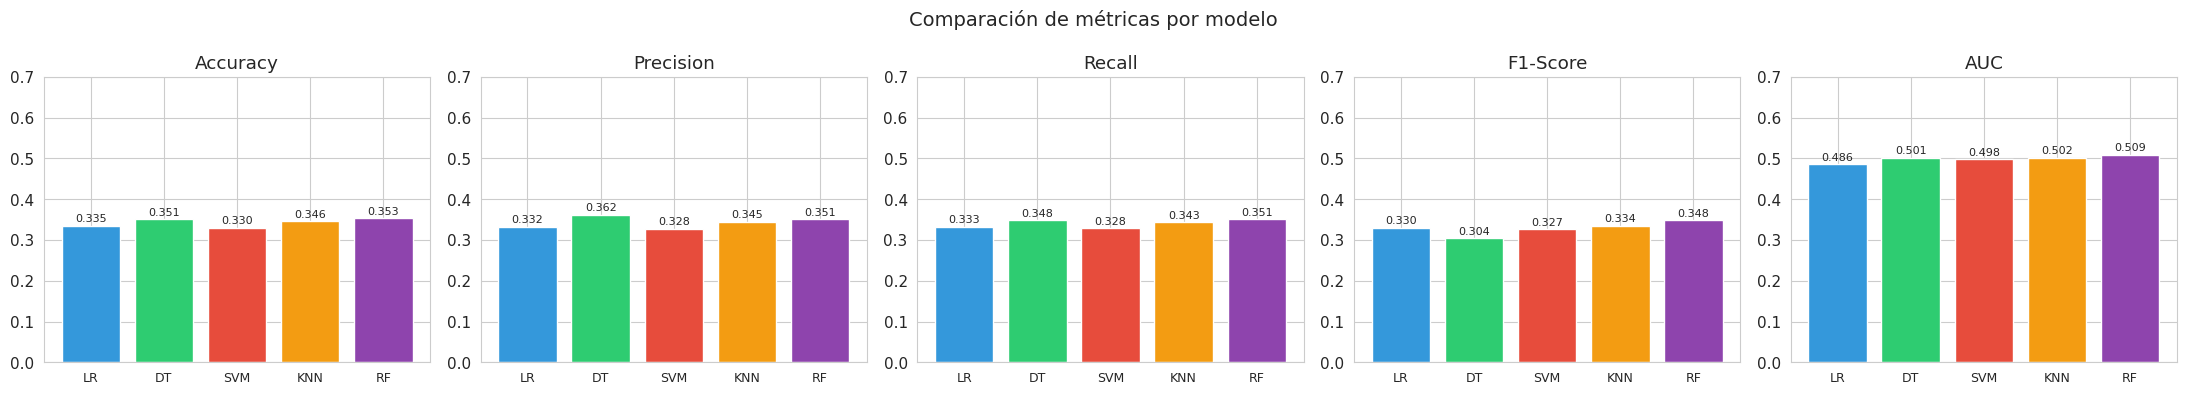

In [134]:
# 9.2  Gráfico de barras comparativo
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors_models = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#8e44ad']

for i, metric in enumerate(metric_names):
    values = [all_metrics[m][metric] for m in all_metrics]
    axes[i].bar(range(len(values)), values, color=colors_models)
    axes[i].set_title(metric)
    axes[i].set_ylim(0.0, 0.7)
    axes[i].set_xticks(range(len(values)))
    axes[i].set_xticklabels(['LR', 'DT', 'SVM', 'KNN', 'RF'], fontsize=9)
    for j, v in enumerate(values):
        axes[i].text(j, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

plt.suptitle('Comparación de métricas por modelo', fontsize=14)
plt.tight_layout()
plt.show()

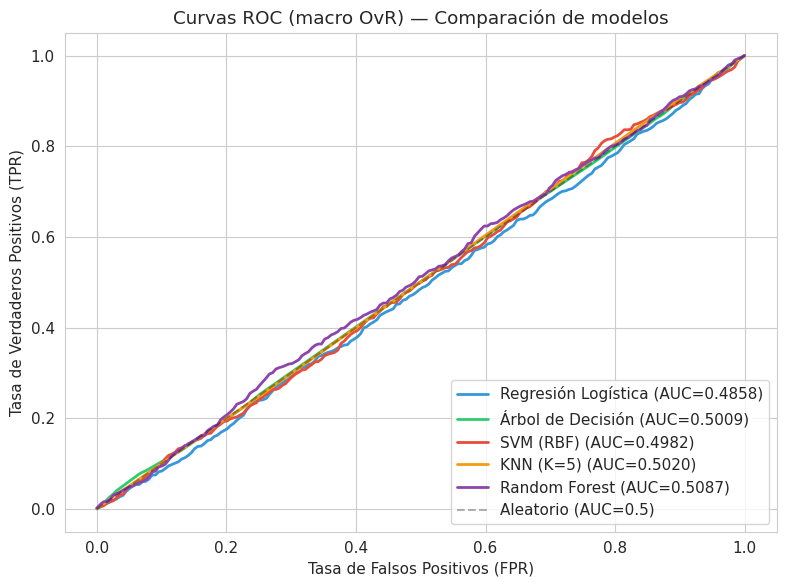

In [135]:
# 9.3  Curvas ROC superpuestas (promedio macro One-vs-Rest)
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(all_models.items(), colors_models):
    fpr_grid, tpr_mean, roc_auc_val = roc_macro_curve(model, X_test, y_test)
    ax.plot(fpr_grid, tpr_mean, linewidth=2, color=color,
            label=f'{name} (AUC={roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC (macro OvR) — Comparación de modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [136]:
# 9.4  Matriz de selección
# "Precisión predictiva" y "Velocidad" se calculan con los resultados medidos en este dataset;
# el resto de criterios son propiedades generales de cada algoritmo (como en el notebook original).
def stars(n):
    n = int(max(1, min(5, n)))
    return '★' * n + '☆' * (5 - n)

cv_f1 = {
    'Regresión Logística': cv_lr['test_f1_macro'].mean(),
    'Árbol de Decisión': cv_dt['test_f1_macro'].mean(),
    'SVM (RBF)': cv_svm['test_f1_macro'].mean(),
    'KNN (K=5)': cv_knn['test_f1_macro'].mean(),
    'Random Forest': cv_rf['test_f1_macro'].mean()
}
best_f1 = max(cv_f1.values())
pred_stars = {m: stars(5 - round((best_f1 - v) / 0.01)) for m, v in cv_f1.items()}   # 1 estrella menos por cada 0.01 de F1 macro

fit_times = {}
for name, model in all_models.items():
    t0 = time.time()
    m = clone(model).fit(X_train, y_train)
    m.predict(X_test)
    fit_times[name] = time.time() - t0
order = sorted(fit_times, key=fit_times.get)                 # de más rápido a más lento
speed_stars = {m: stars(5 - i) for i, m in enumerate(order)}

selection_matrix = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'Árbol de Decisión', 'SVM (RBF)', 'KNN', 'Random Forest'],
    'Precisión predictiva': [pred_stars[m] for m in all_models],
    'Velocidad (train+pred)': [speed_stars[m] for m in all_models],
    'Interpretabilidad': ['★★★★☆', '★★★★★', '★★☆☆☆', '★★★☆☆', '★★☆☆☆'],
    'Escalabilidad': ['★★★★★', '★★★★☆', '★★☆☆☆', '★★☆☆☆', '★★★★☆'],
    'Robustez a outliers': ['★★★☆☆', '★★★★☆', '★★★★☆', '★★☆☆☆', '★★★★★']
}).set_index('Modelo')

print('=== Matriz de Selección de Modelos ===')
print('Tiempos train+pred (s): ' + ', '.join(f'{m}: {t:.2f}' for m, t in fit_times.items()))
selection_matrix

=== Matriz de Selección de Modelos ===
Tiempos train+pred (s): Regresión Logística: 0.02, Árbol de Decisión: 0.02, SVM (RBF): 3.12, KNN (K=5): 0.03, Random Forest: 1.33


,Precisión predictiva,Velocidad (train+pred),Interpretabilidad,Escalabilidad,Robustez a outliers
Modelo,,,,,
Reg. Logística,★★★★★,★★★★★,★★★★☆,★★★★★,★★★☆☆
Árbol de Decisión,★★☆☆☆,★★★★☆,★★★★★,★★★★☆,★★★★☆
SVM (RBF),★★★★★,★☆☆☆☆,★★☆☆☆,★★☆☆☆,★★★★☆
KNN,★★★★★,★★★☆☆,★★★☆☆,★★☆☆☆,★★☆☆☆
Random Forest,★★★★★,★★☆☆☆,★★☆☆☆,★★★★☆,★★★★★


---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Reg. Logística** | Interpretable, probabilística, rápida | Asume linealidad en log-odds | Clasificación con necesidad de interpretabilidad y baseline rápido |
| **Árbol de Decisión** | Explicable, maneja tipos mixtos | Propenso a sobreajuste sin poda; con clases balanceadas tiende a favorecer una sola clase | Reglas de negocio, explicabilidad ante stakeholders |
| **SVM** | Efectivo en alta dimensión, robusto al ruido | Lento con muchos datos, difícil de interpretar | Datasets de dimensión media-alta con márgenes claros |
| **KNN** | Simple, no paramétrico, flexible | Lento en predicción, sensible a la escala y a la dimensionalidad (más con one-hot) | Datasets pequeños-medianos con features normalizadas |
| **Random Forest** | Reduce la varianza del árbol, maneja mezcla de numéricas y categóricas, da importancia de features | Menos interpretable que un árbol, más costoso en memoria | Datos tabulares con relaciones no lineales e interacciones |

**Resultados en el Test Set (1 000 muestras, promedio macro):**

| Modelo | Accuracy | F1 (macro) | AUC (macro OvR) |
|---|---|---|---|
| Reg. Logística | 0.335 | 0.330 | 0.486 |
| Árbol de Decisión | 0.351 | 0.304 | 0.501 |
| SVM (RBF) | 0.330 | 0.327 | 0.498 |
| KNN (K=5) | 0.346 | 0.334 | 0.502 |
| **Random Forest** | **0.353** | **0.348** | **0.509** |

**Criterio de selección final:** el target tiene 3 clases casi equilibradas (34.6 % / 32.0 % / 33.5 %), por lo que se prioriza el **F1-Score macro** (trata igual a las tres clases) apoyado por el **AUC macro OvR**. Con ese criterio el mejor modelo en test es **Random Forest**, que lidera Accuracy, Recall, F1 macro y AUC, y además captura las tres clases (el árbol podado casi nunca predice `Medium`).

**Justificación y advertencia:** la ventaja de Random Forest es **nominal**. Todos los modelos rinden cerca del azar (Accuracy ≈ 0.33 con 3 clases, AUC ≈ 0.50), y en validación cruzada LR, SVM, KNN y Random Forest quedan empatados (F1 macro ≈ 0.316–0.319). Con 1 000 muestras de test el error estándar de la accuracy es de ≈ 1.5 puntos, así que las diferencias entre modelos no son estadísticamente concluyentes. En la práctica, **ninguno de los modelos es apto para desplegarse**: las variables disponibles (plataforma, hashtag, tipo de contenido, región, vistas, likes, shares y comentarios) no explican el nivel de engagement en este dataset. Como candidato se recomienda Random Forest, y como siguiente paso revisar cómo se definió `Engagement_Level` y añadir variables con señal real (por ejemplo tasas como likes/vistas, horario de publicación o seguidores).